In [1]:
%load_ext autoreload
%autoreload 3

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/shared_helper_modules'))

# General imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
import pickle

warnings.filterwarnings(
    "ignore",
    message="use_inf_as_na option is deprecated",
    category=FutureWarning,
    module="seaborn")

warnings.filterwarnings(
    "ignore",
    message=r"invalid value encountered in log10",
    category=RuntimeWarning,
    module=r".*specparam.*",
)


# NeuroDSP and FOOOF modules
from neurodsp import spectral

from specparam import Bands


# Custom modules

from spk_feat_cluster_analysis import *

from spe1_plotting import *
from spikeparam.patch.fit import Spike

from config import NPX_CHANNELS, CELL_IDS, DICT_PATCH_FS, DICT_CHAN_PRED, DICT_SPK_THRESH, FILTER_SETTINGS


In [3]:
cell_num = 46 #MODIFY THIS WHEN RUNNING DIFFERENT CELLS 

npx_fs = 30000 # sampling rate
lfp_fs = 3500 # sampling rate

patch_fs = DICT_PATCH_FS[cell_num ]
spk_thresh = DICT_SPK_THRESH[cell_num]

npx_channels = NPX_CHANNELS
npx_patch_channel = DICT_CHAN_PRED[cell_num ]

### Loading spe-1 data:

I moved the data loading steps to a separate Jupyter Notebook (spe-1_load_data)




## Cell   
### Analyze Gamma LFP and whole patch clamp AP relationship for cell 

## Step 0: Get loaded data 

In [4]:
lfp_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings/c46_lfp.npy'
patch_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c46_patch.npy'


In [5]:
#get cell number 
cell_num = lfp_dir.split('/')[len(lfp_dir.split('/'))-1].split('_')[0]

#get LFP data
lfp_filt = np.load(lfp_dir)
lfp_one_ms = float(lfp_fs / 1000)
lfp_times = np.arange(0, np.shape(lfp_filt)[0]) / lfp_one_ms # in ms instead of sec

#get patch data 
patch_filt = np.load(patch_dir)
patch_one_ms = float(patch_fs  / 1000)
patch_times = np.arange(0, np.shape(patch_filt )[0]) / patch_one_ms # in ms instead of sec

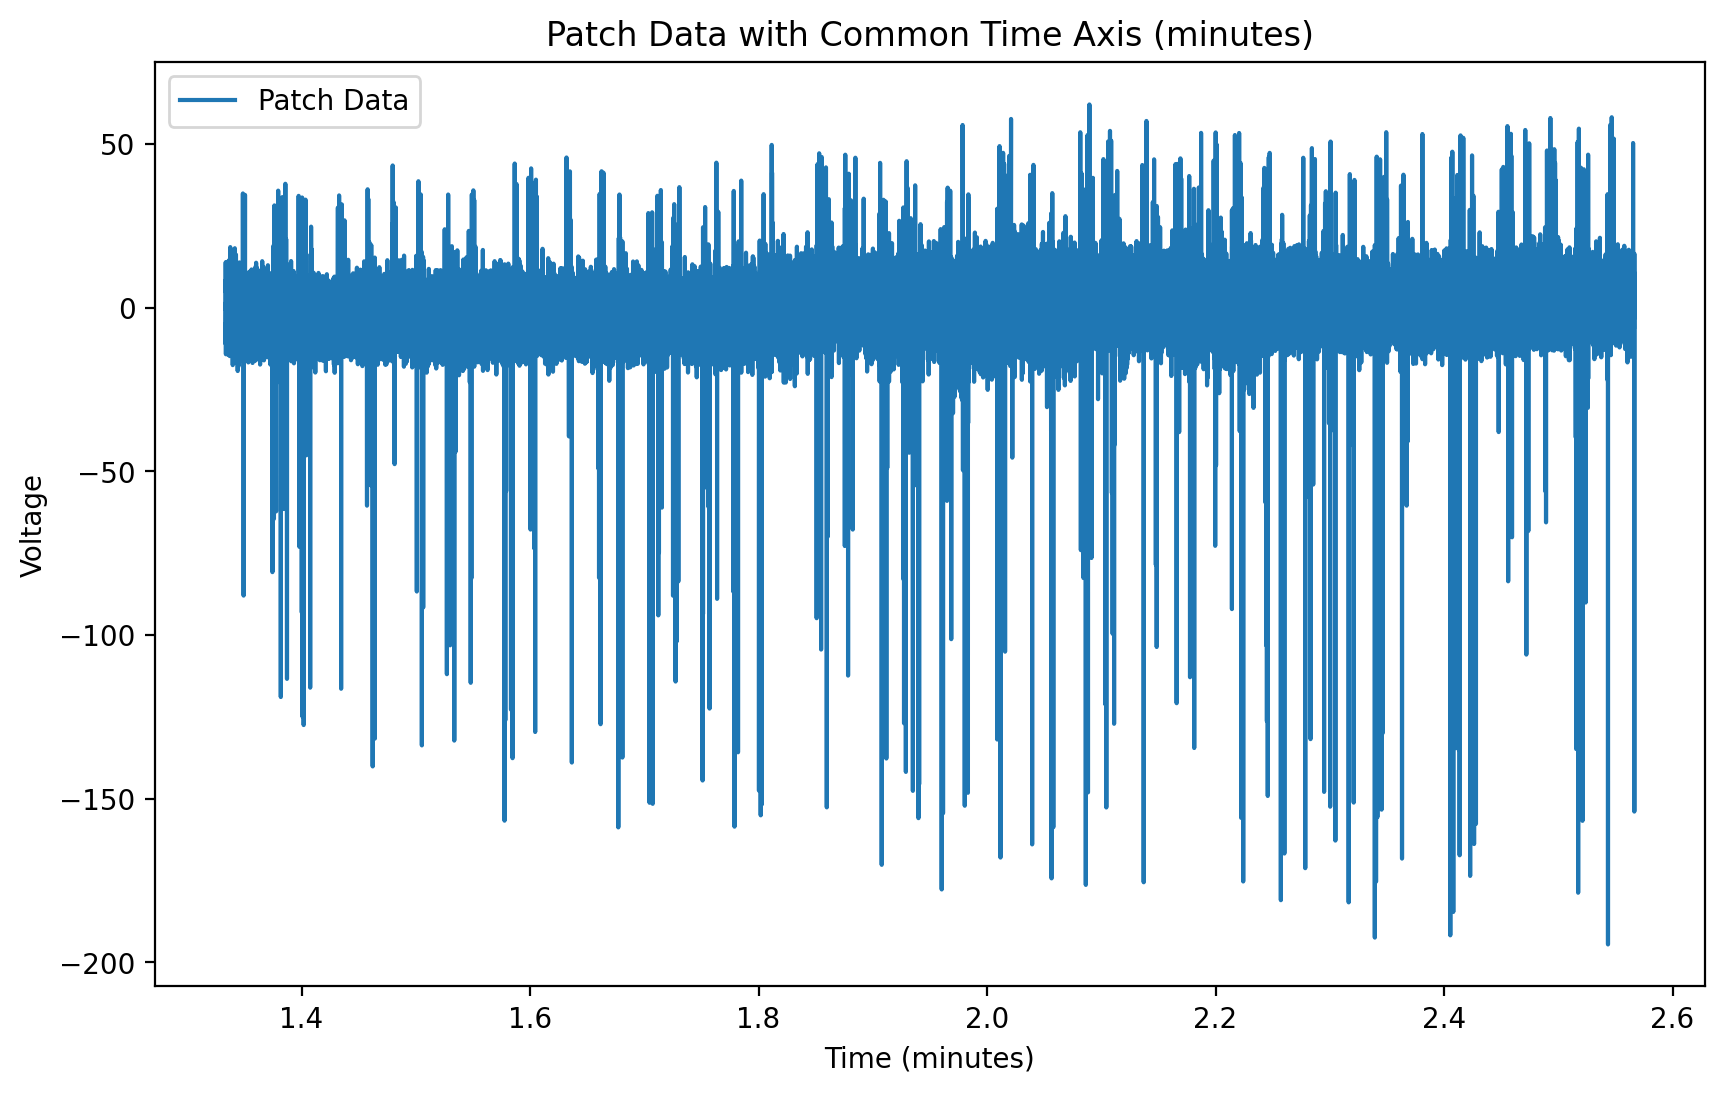

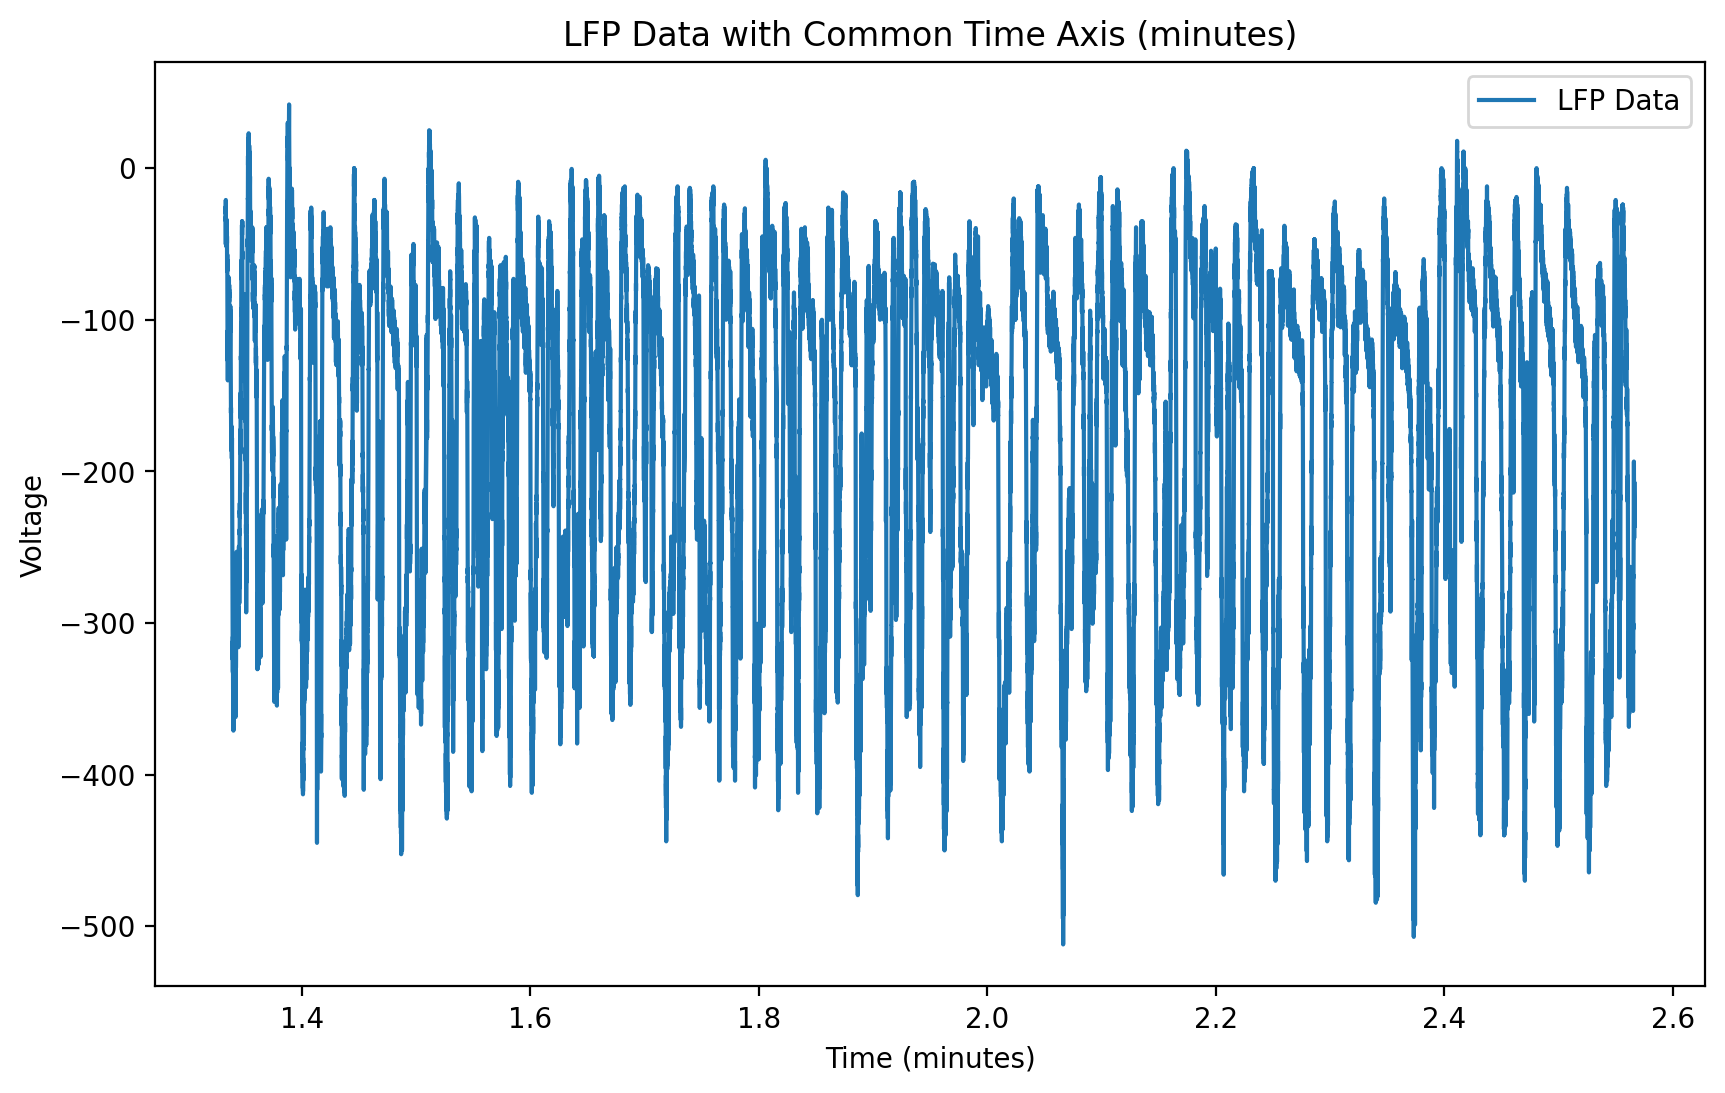

In [6]:
# Plot simultaneous patch and LFP data
# Convert time arrays to minutes
patch_times_min = patch_times / 60000  # Convert milliseconds to minutes
lfp_times_min = lfp_times / 60000  # Convert milliseconds to minutes

# Set the common time axis in minutes (e.g., from 13.3333 to 35.6667 minutes)
common_time_range_min = np.arange(80000 / 60000, 154000 / 60000, 1 / 60000)  # Adjust as needed

# Interpolate patch data onto the common time axis
patch_interp = np.interp(common_time_range_min, patch_times_min, patch_filt)

# Interpolate LFP data onto the common time axis
lfp_interp = np.interp(common_time_range_min, lfp_times_min, lfp_filt)

# Plot patch data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, patch_interp, label='Patch Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('Patch Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

# Plot LFP data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, lfp_interp, label='LFP Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('LFP Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

## STEP 1: Detect and fit spikes from patch data

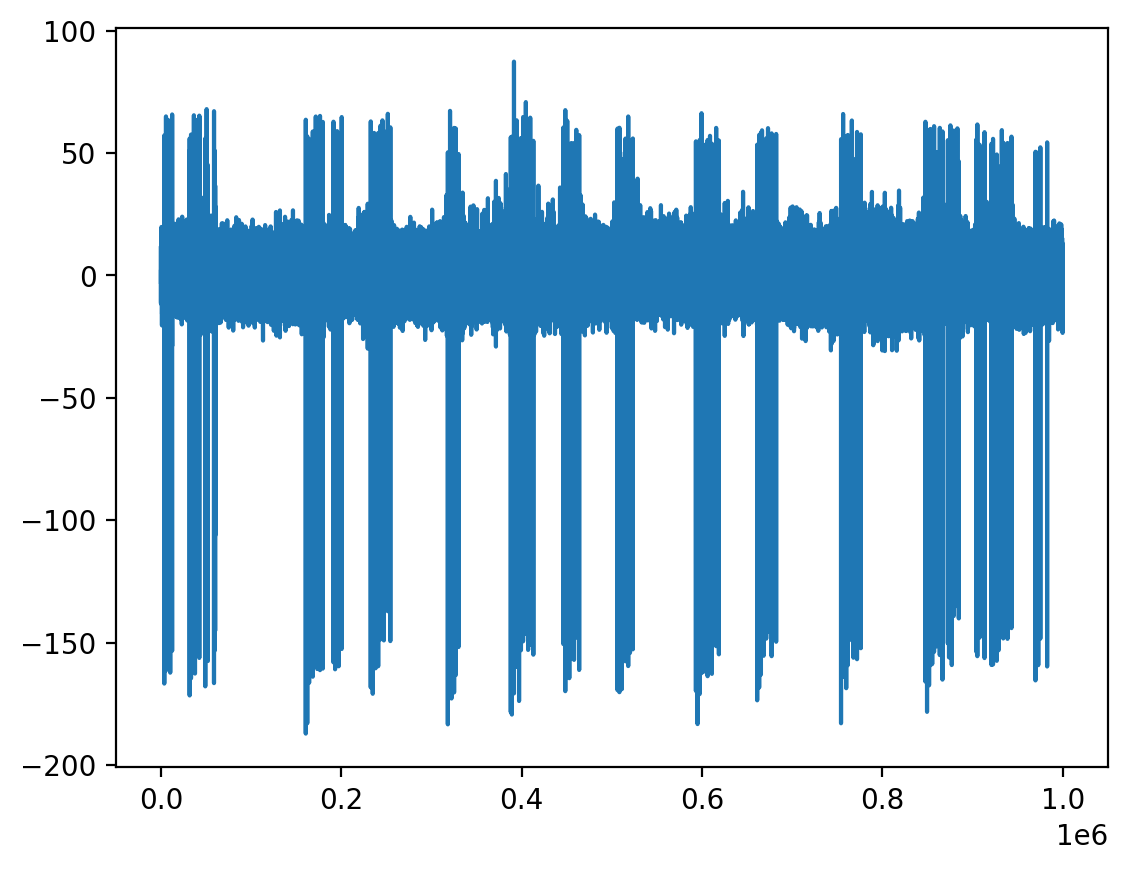

In [7]:
plt.plot(patch_filt[:1000000] )

In [25]:



#threshold in mVs
sp = Spike(thresh_amp=spk_thresh, window_length=(5., 5.), smooth_frac=.01)

In [26]:
#CHANGE FOR EACH CELL
sp.fit(patch_filt, patch_fs, n_jobs=-1, progress=tqdm, flip_signal=True)

Spike:   0%|          | 0/6192 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


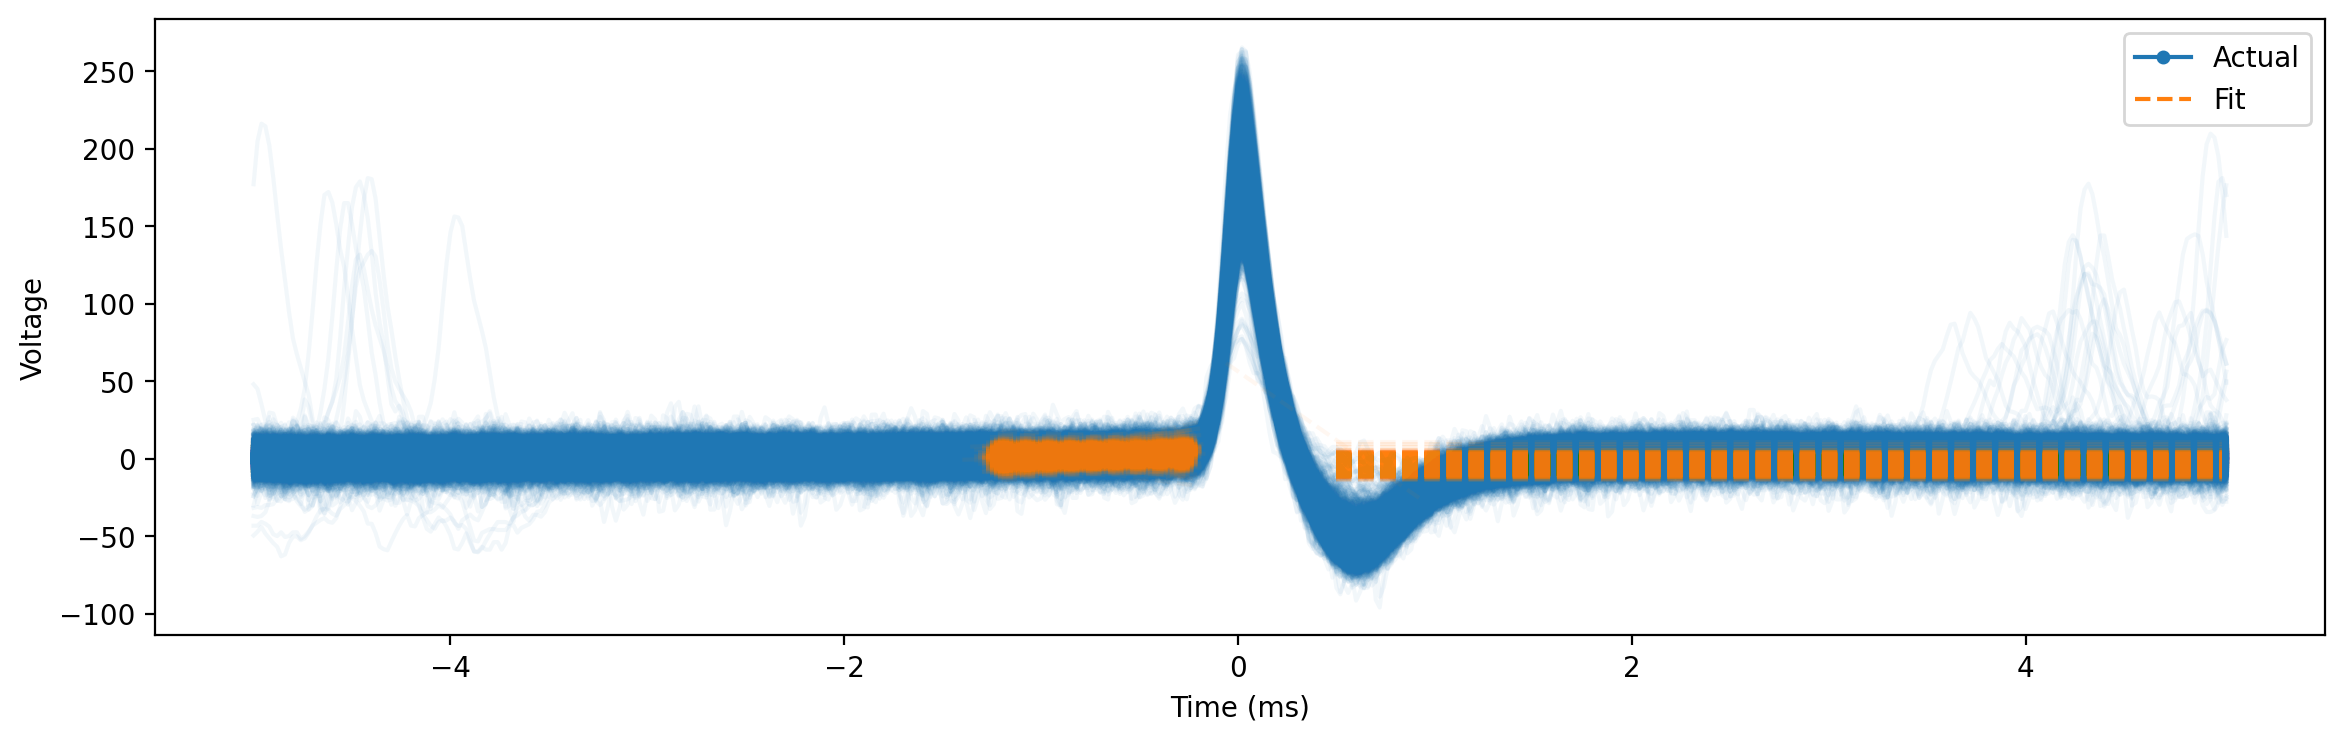

In [27]:
sp.plot()

### Filter spikes 

In [33]:
sp.filter_features()  # Applies default filters in-place

### Get spike dataframe (with spike times column)

In [34]:

df_features = sp.df_features

#add columns for spike times, both in idx and ms
df_features['spk_times_idx'] = sp.spike_inds
df_features['spk_times_ms'] = patch_times[sp.spike_inds]
df_features['spk_id'] = range(len(df_features))

In [35]:
df_features

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,spk_times_idx,spk_times_ms,spk_id,log_isi
12,4.603323,0.22,-6.972072,145.628132,0.20,82.362489,7.711234e-06,-9.758882,50666,1012.836360,0,1.441959
31,3.955364,0.24,4.930935,167.273557,0.20,87.878336,1.461031e-05,-2.179672,234888,4695.517841,1,1.488061
113,4.097219,0.24,-2.735549,133.372303,0.20,67.140789,1.399156e-05,-5.510915,875425,17500.143496,2,1.486931
143,4.213371,0.22,9.724557,157.441815,0.20,84.474648,1.639628e-05,-1.153772,1065572,21301.268419,3,1.503311
154,5.895421,0.20,1.556716,140.740901,0.20,71.136001,6.321530e-06,-5.467531,1122308,22435.446837,4,1.689811
184,3.498355,0.24,-3.323533,138.297022,0.22,72.654117,7.720567e-06,-7.375605,1310181,26191.113466,5,1.676303
196,-7.633643,0.26,-14.170171,151.224736,0.22,79.982702,3.268217e-06,-11.123839,1409166,28169.868590,6,1.566112
219,-9.405676,0.24,-8.541873,144.062809,0.22,75.384914,5.935057e-06,-7.456208,1534197,30669.295087,7,1.535087
241,6.390326,0.20,10.976740,157.454891,0.20,74.774879,2.605099e-06,0.378344,1734383,34671.104181,8,1.549286
286,3.720940,0.24,-3.792753,131.085780,0.20,68.048673,1.961692e-06,-8.886899,2061844,41217.198352,9,1.827550


### Get spike times


In [36]:
spk_times_idx = df_features['spk_times_idx']
spk_times_ms = df_features['spk_times_ms']
spk_ids = df_features['spk_id']

In [37]:
df_features.columns

Index(['ramp_amp', 'inflection_time', 'inflection_amp', 'peak_amp',
       'peak_width', 'peak_sharpness', 'exp_lambda', 'exp_const',
       'spk_times_idx', 'spk_times_ms', 'spk_id', 'log_isi'],
      dtype='object')

## STEP 2: Cluster spike groups 

#### Plot distribution of all features

Plotting spike features...
Removing outliers using IQR method (multiplier=3)


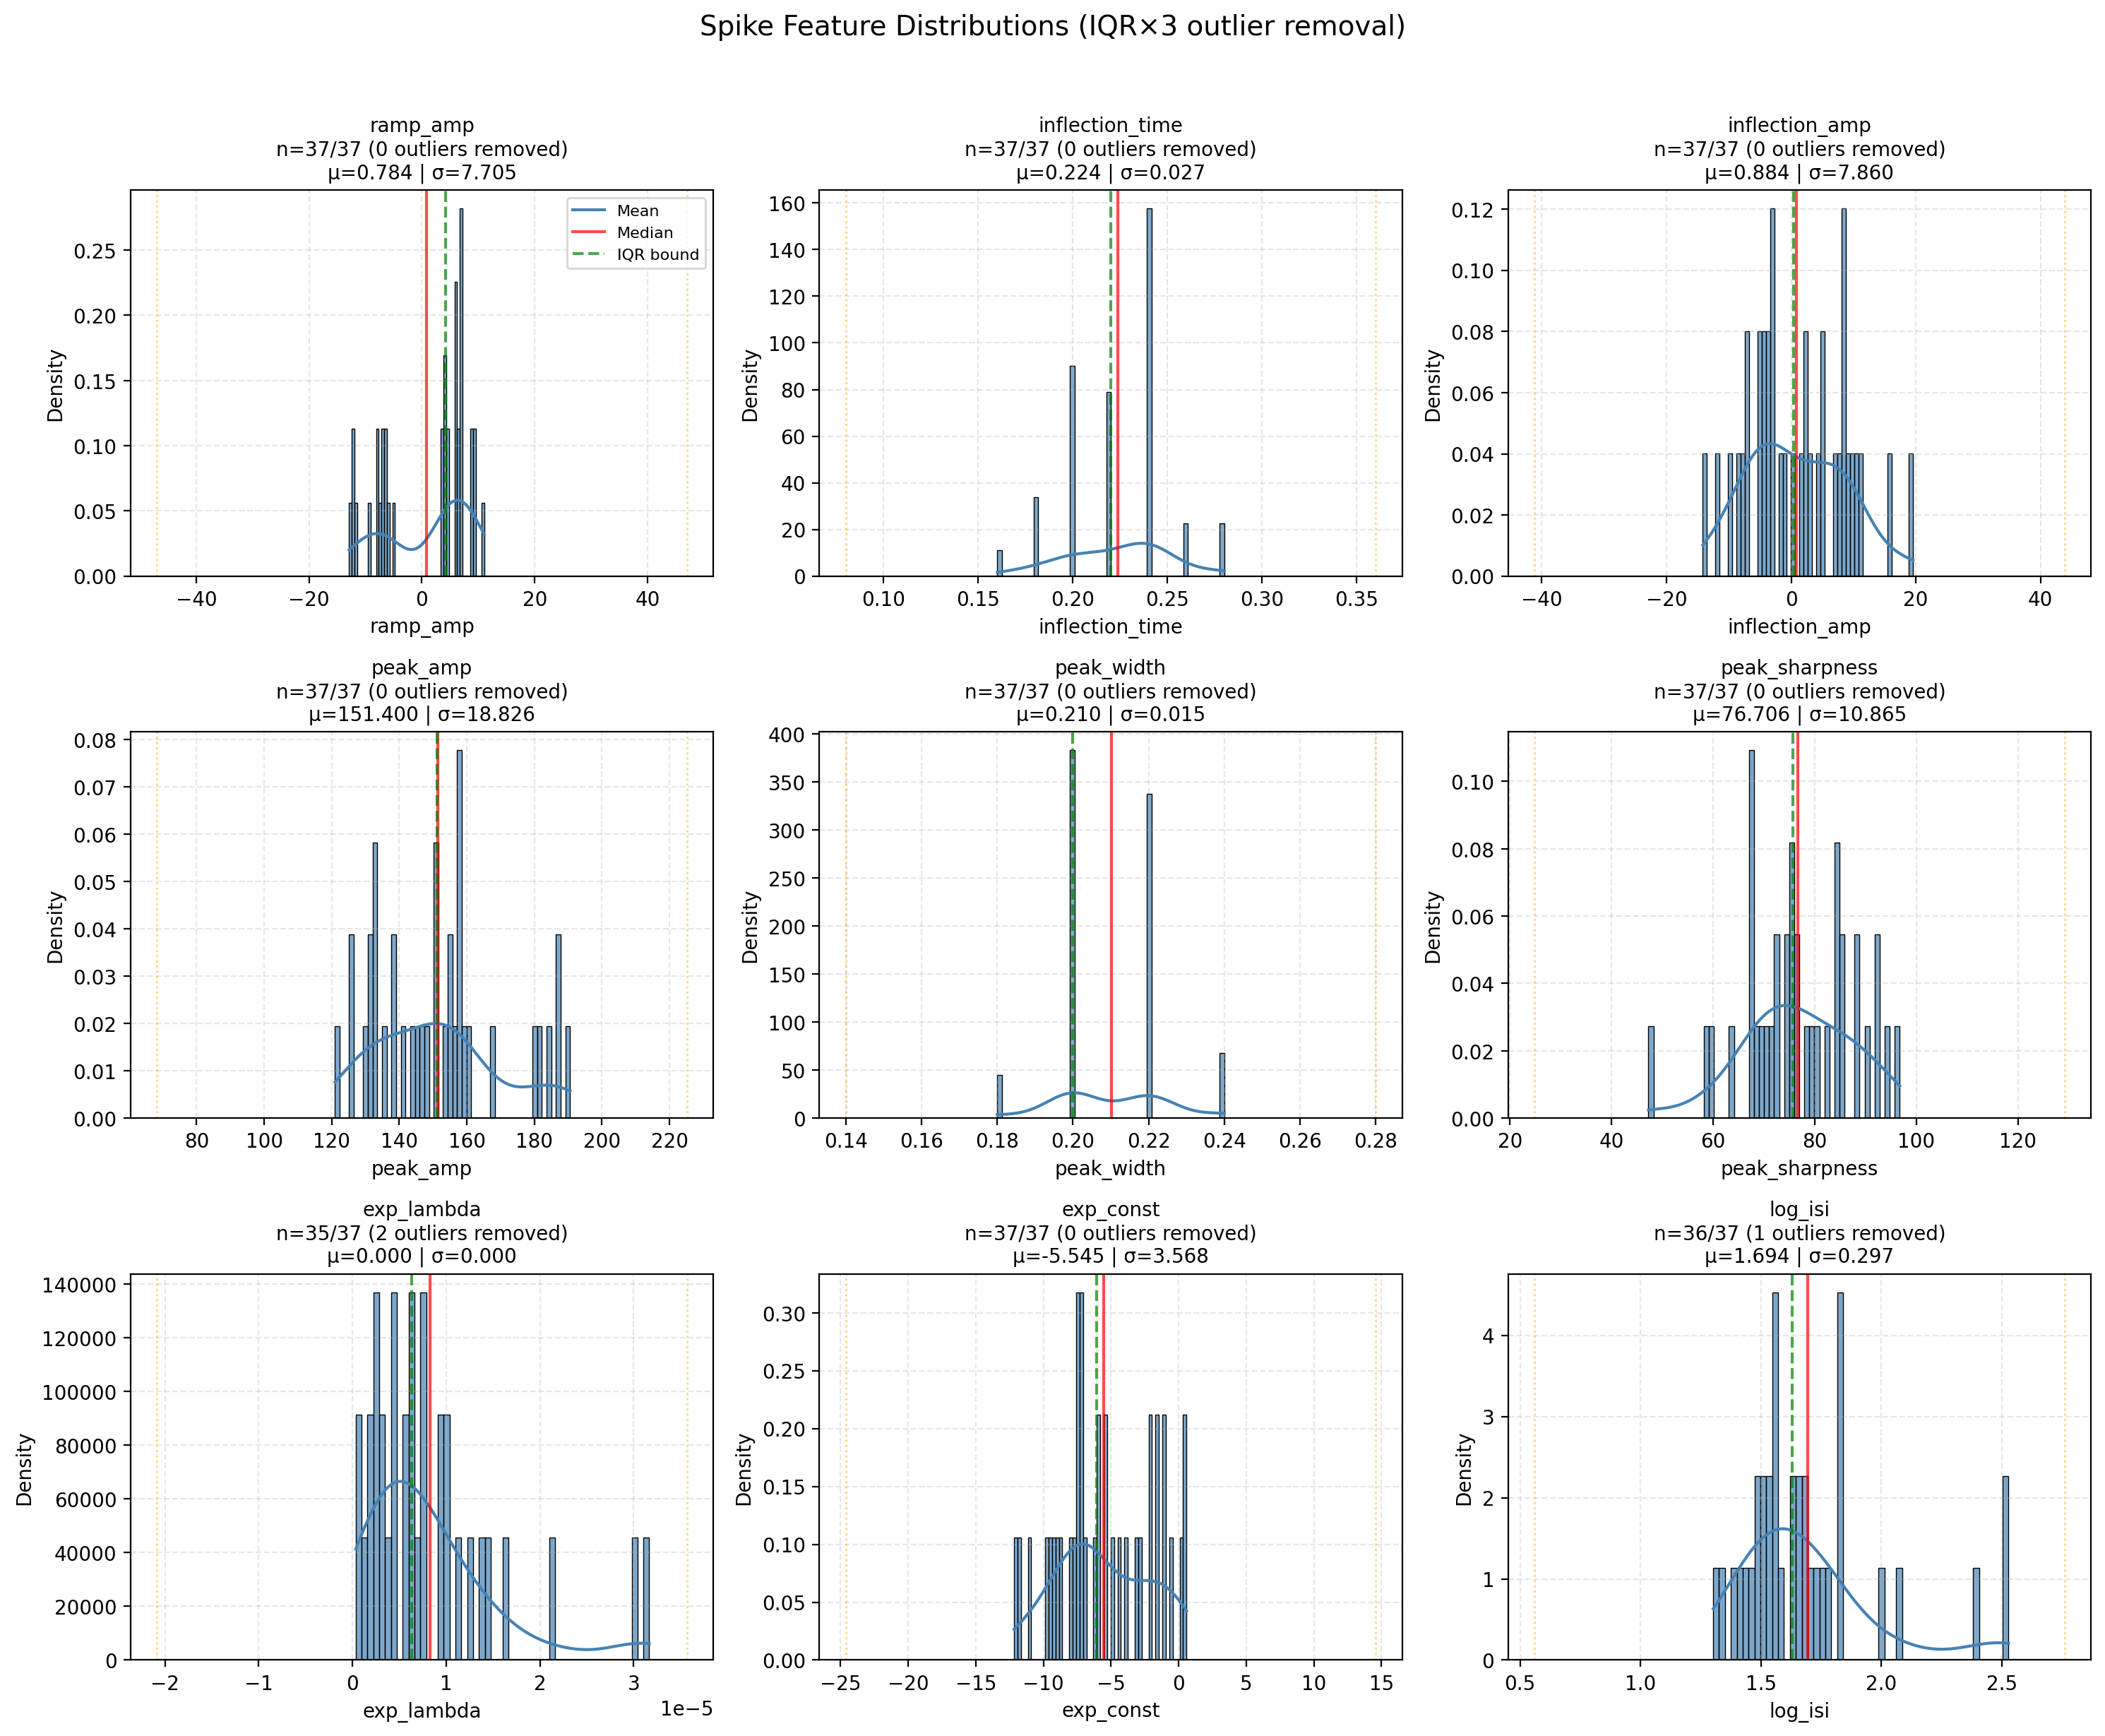


FEATURE DISTRIBUTION SUMMARY
Feature              Total N    Clean N    Outliers   % Removed  Mean       Std       
------------------------------------------------------------------------------------------
ramp_amp             37         37         0          0.0        0.784      7.705     
inflection_time      37         37         0          0.0        0.224      0.027     
inflection_amp       37         37         0          0.0        0.884      7.860     
peak_amp             37         37         0          0.0        151.400    18.826    
peak_width           37         37         0          0.0        0.210      0.015     
peak_sharpness       37         37         0          0.0        76.706     10.865    
exp_lambda           37         35         2          5.4        0.000      0.000     
exp_const            37         37         0          0.0        -5.545     3.568     
log_isi              37         36         1          2.7        1.694      0.297     


In [38]:
plot_spike_feature_distributions(df_features)

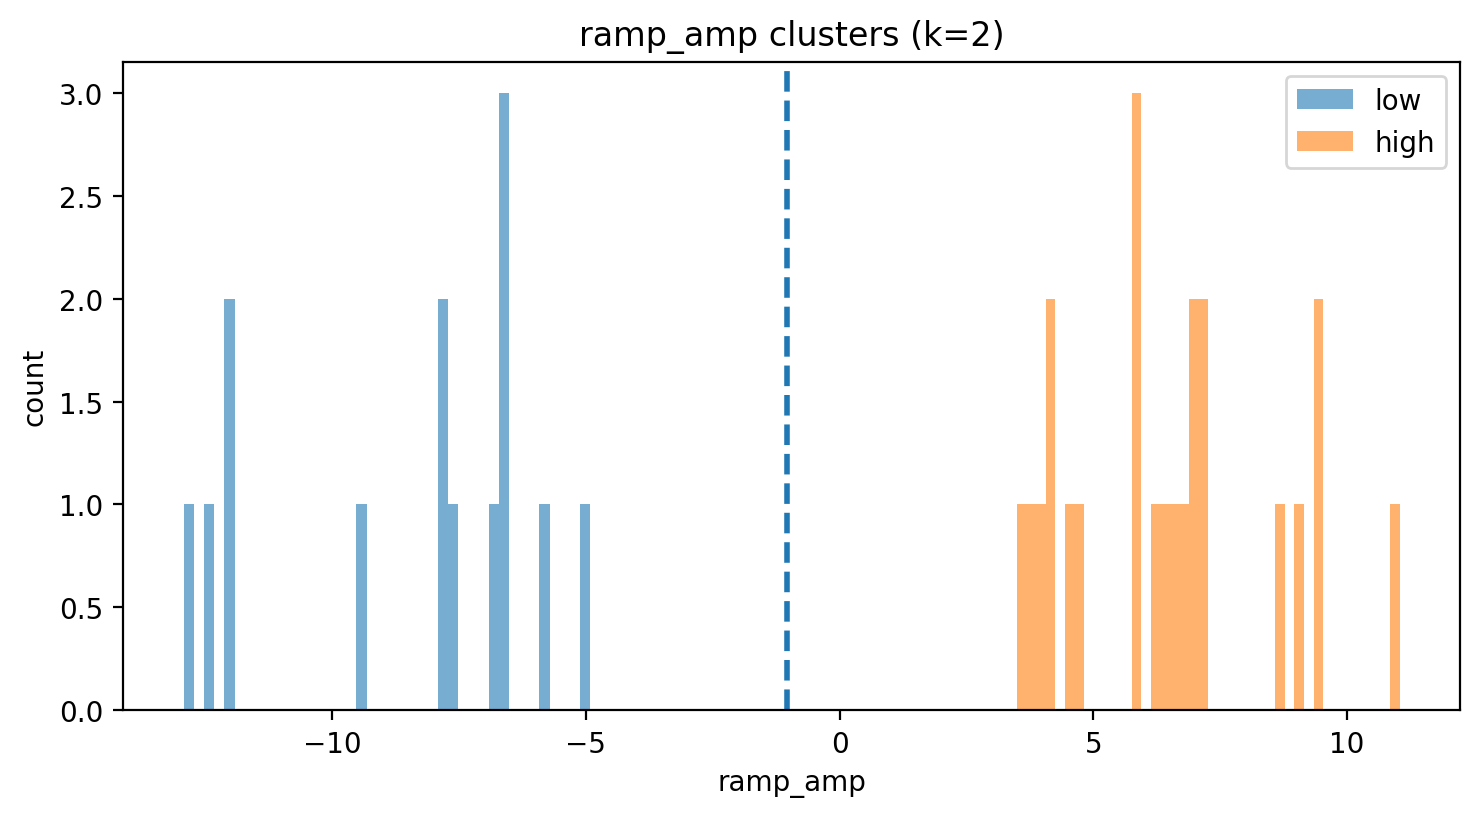

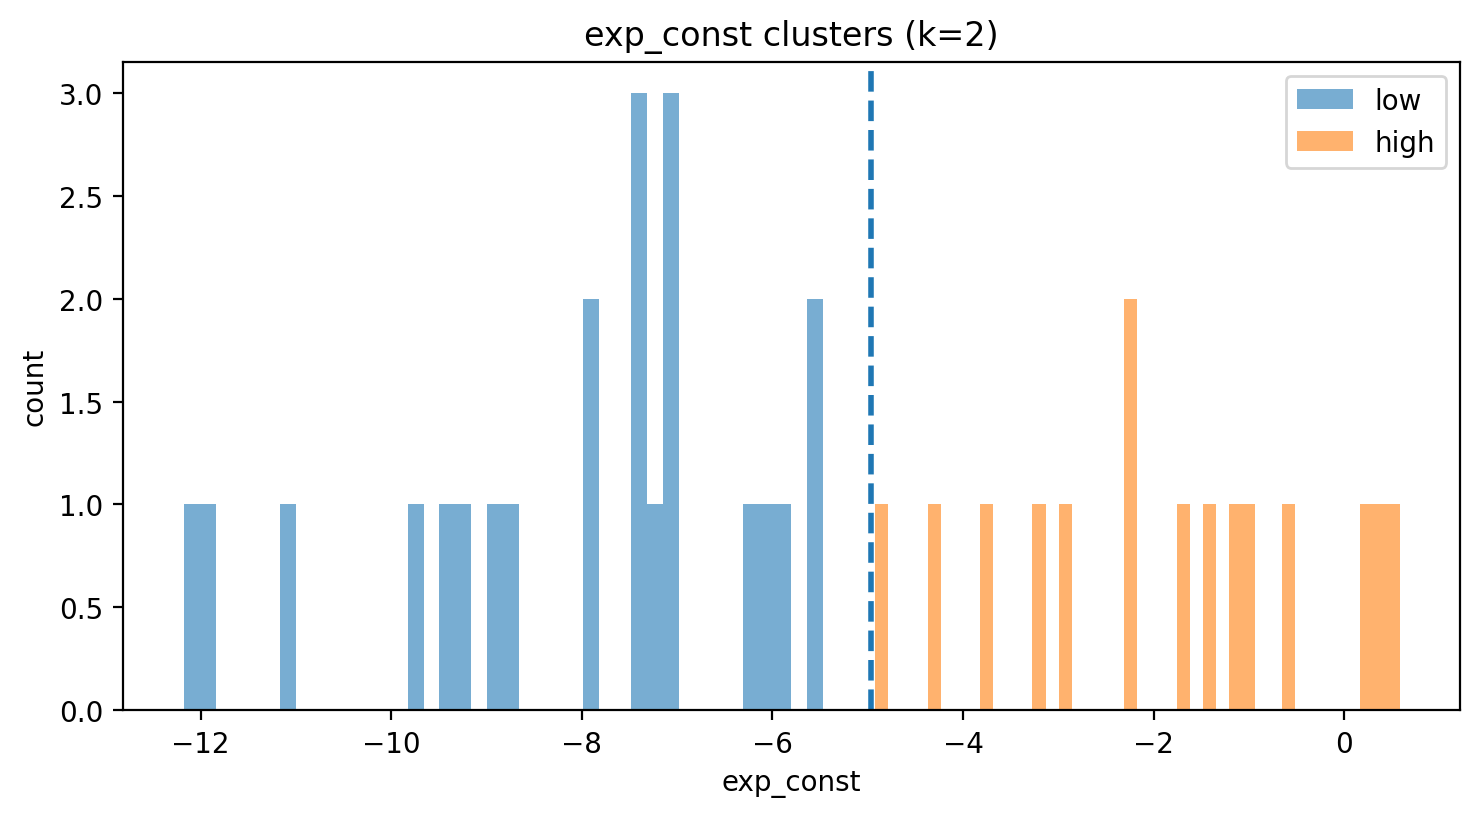

In [39]:
# scan all numeric features and only cluster the ones that look multimodal
df_features_clust, rep = cluster_multimodal_features(
    df_features,
    max_k=2,
    suffix="_cluster",
    plot_each=True,  # set True if you want a quick plot per clustered feature, 
    manual_thresholds={
    }
)





===== CLUSTER REPORT: ramp_amp_cluster =====
→ Plotting spike waveforms by cluster
→ Plotting cluster proportions over time


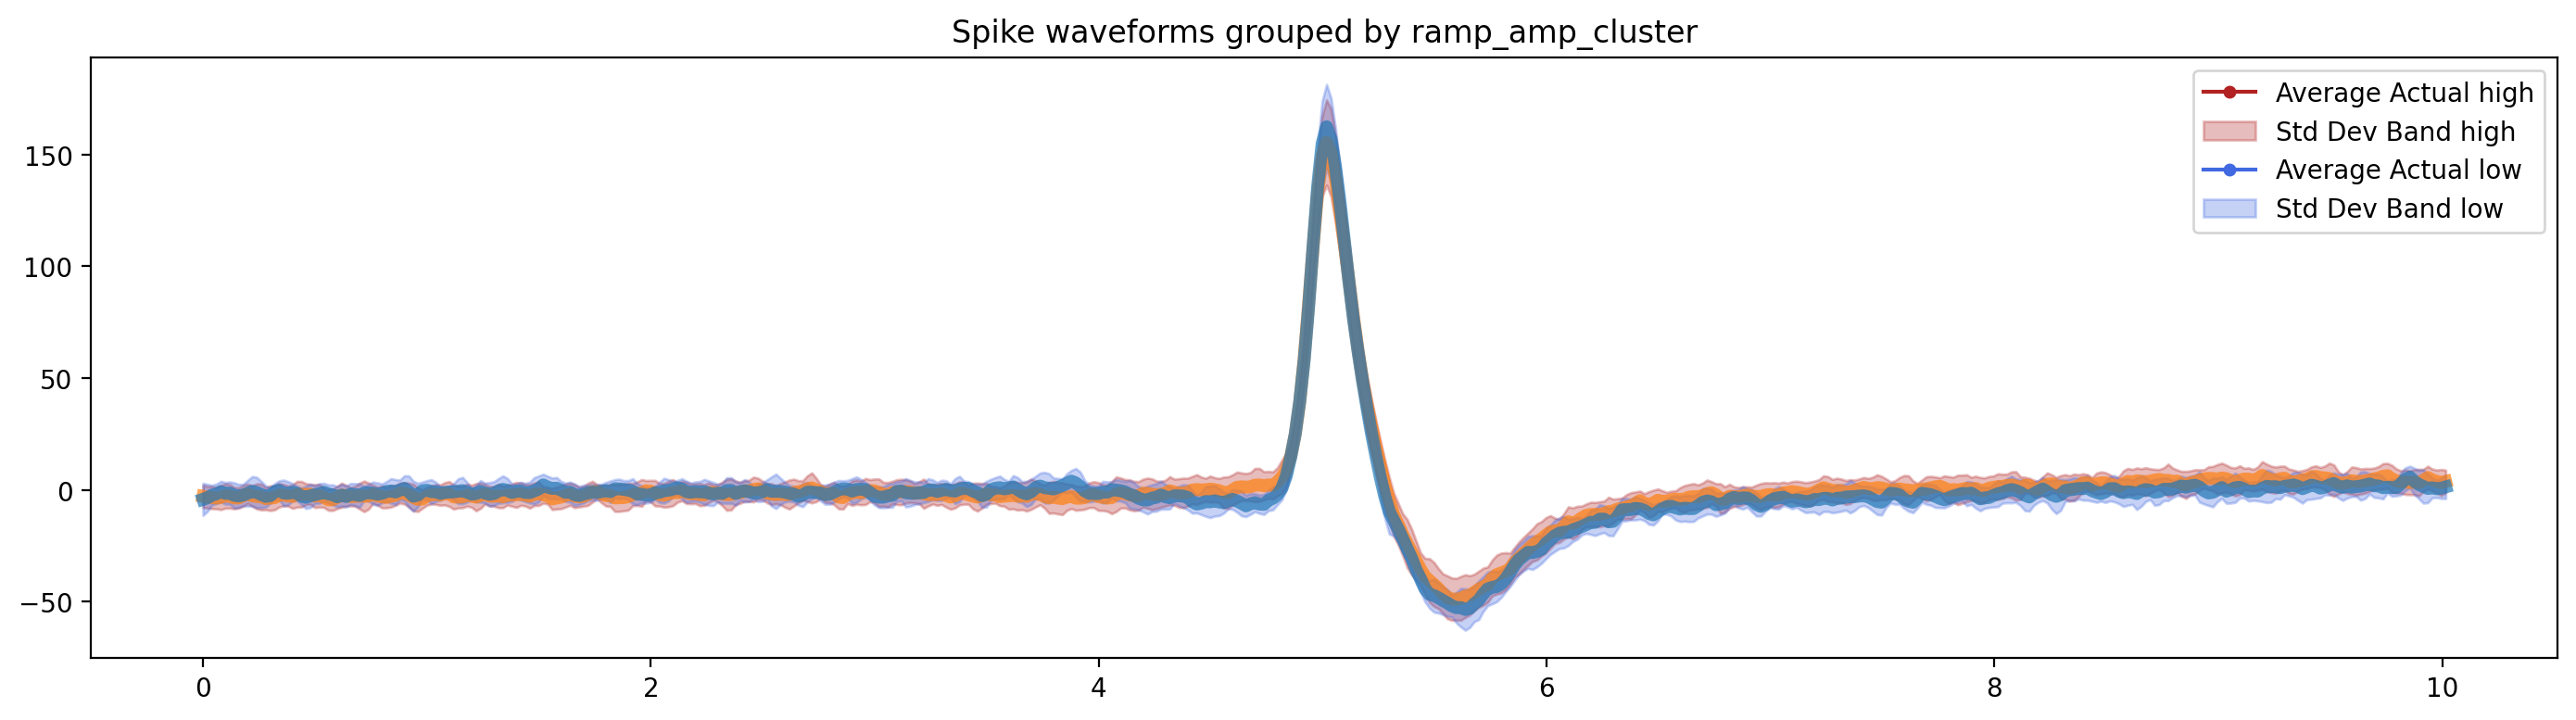

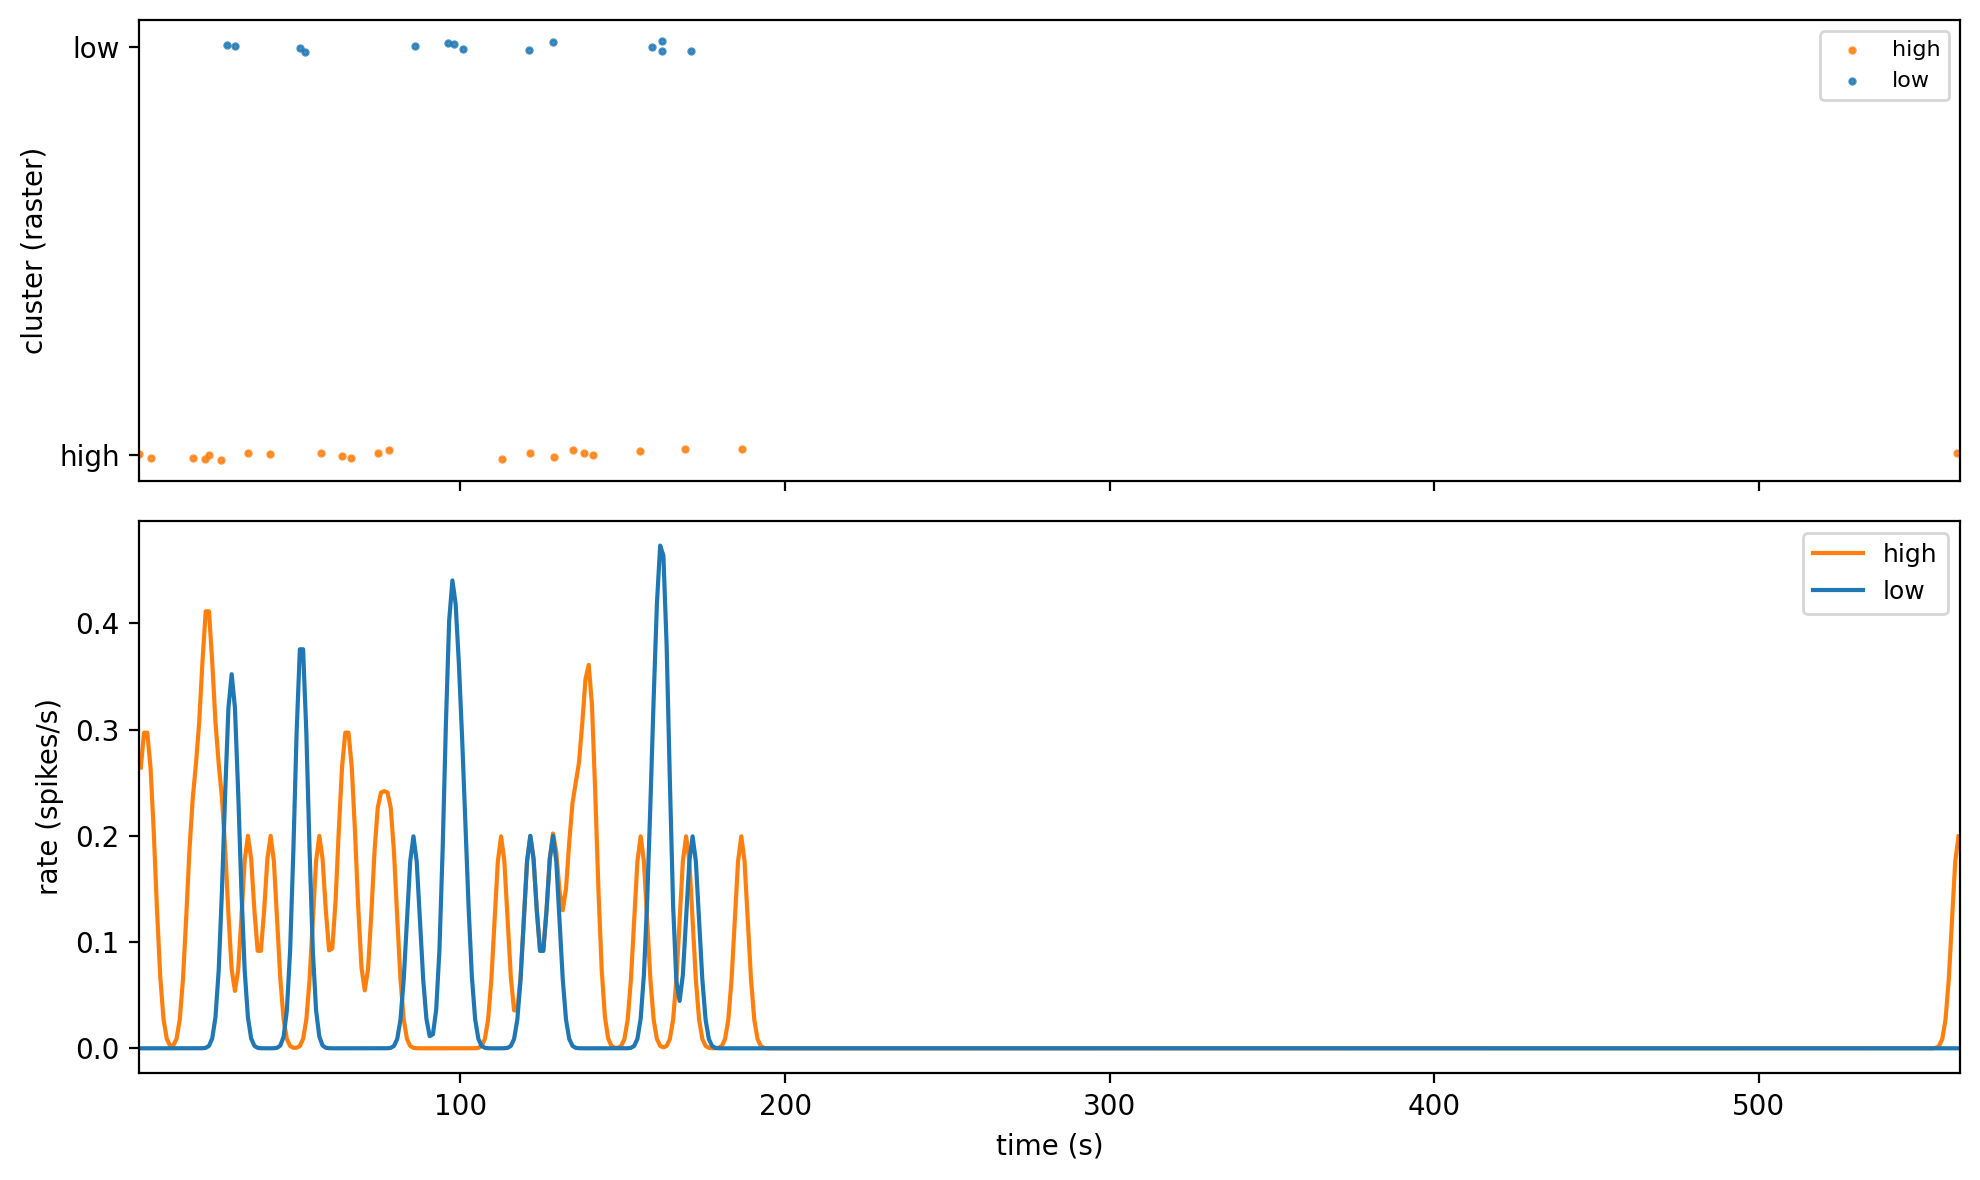

→ Computing cluster transition matrix


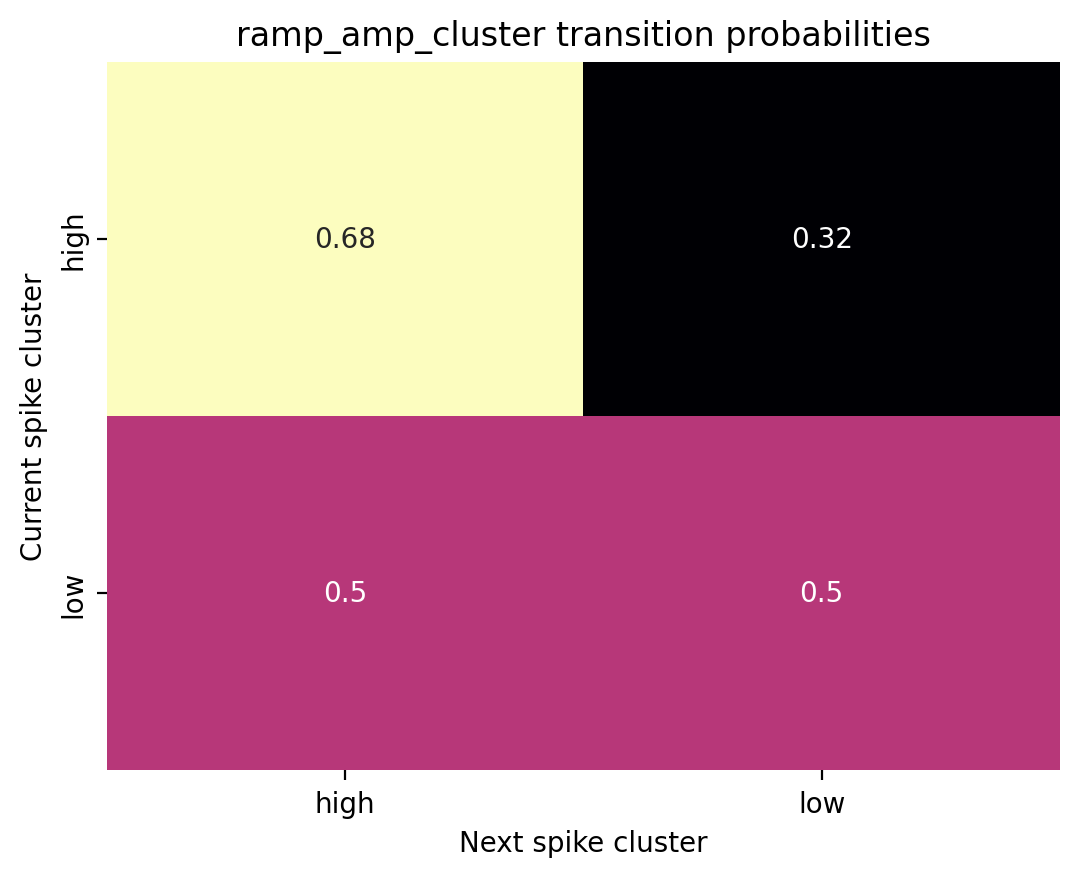

→ Visualizing high vs low feature distributions


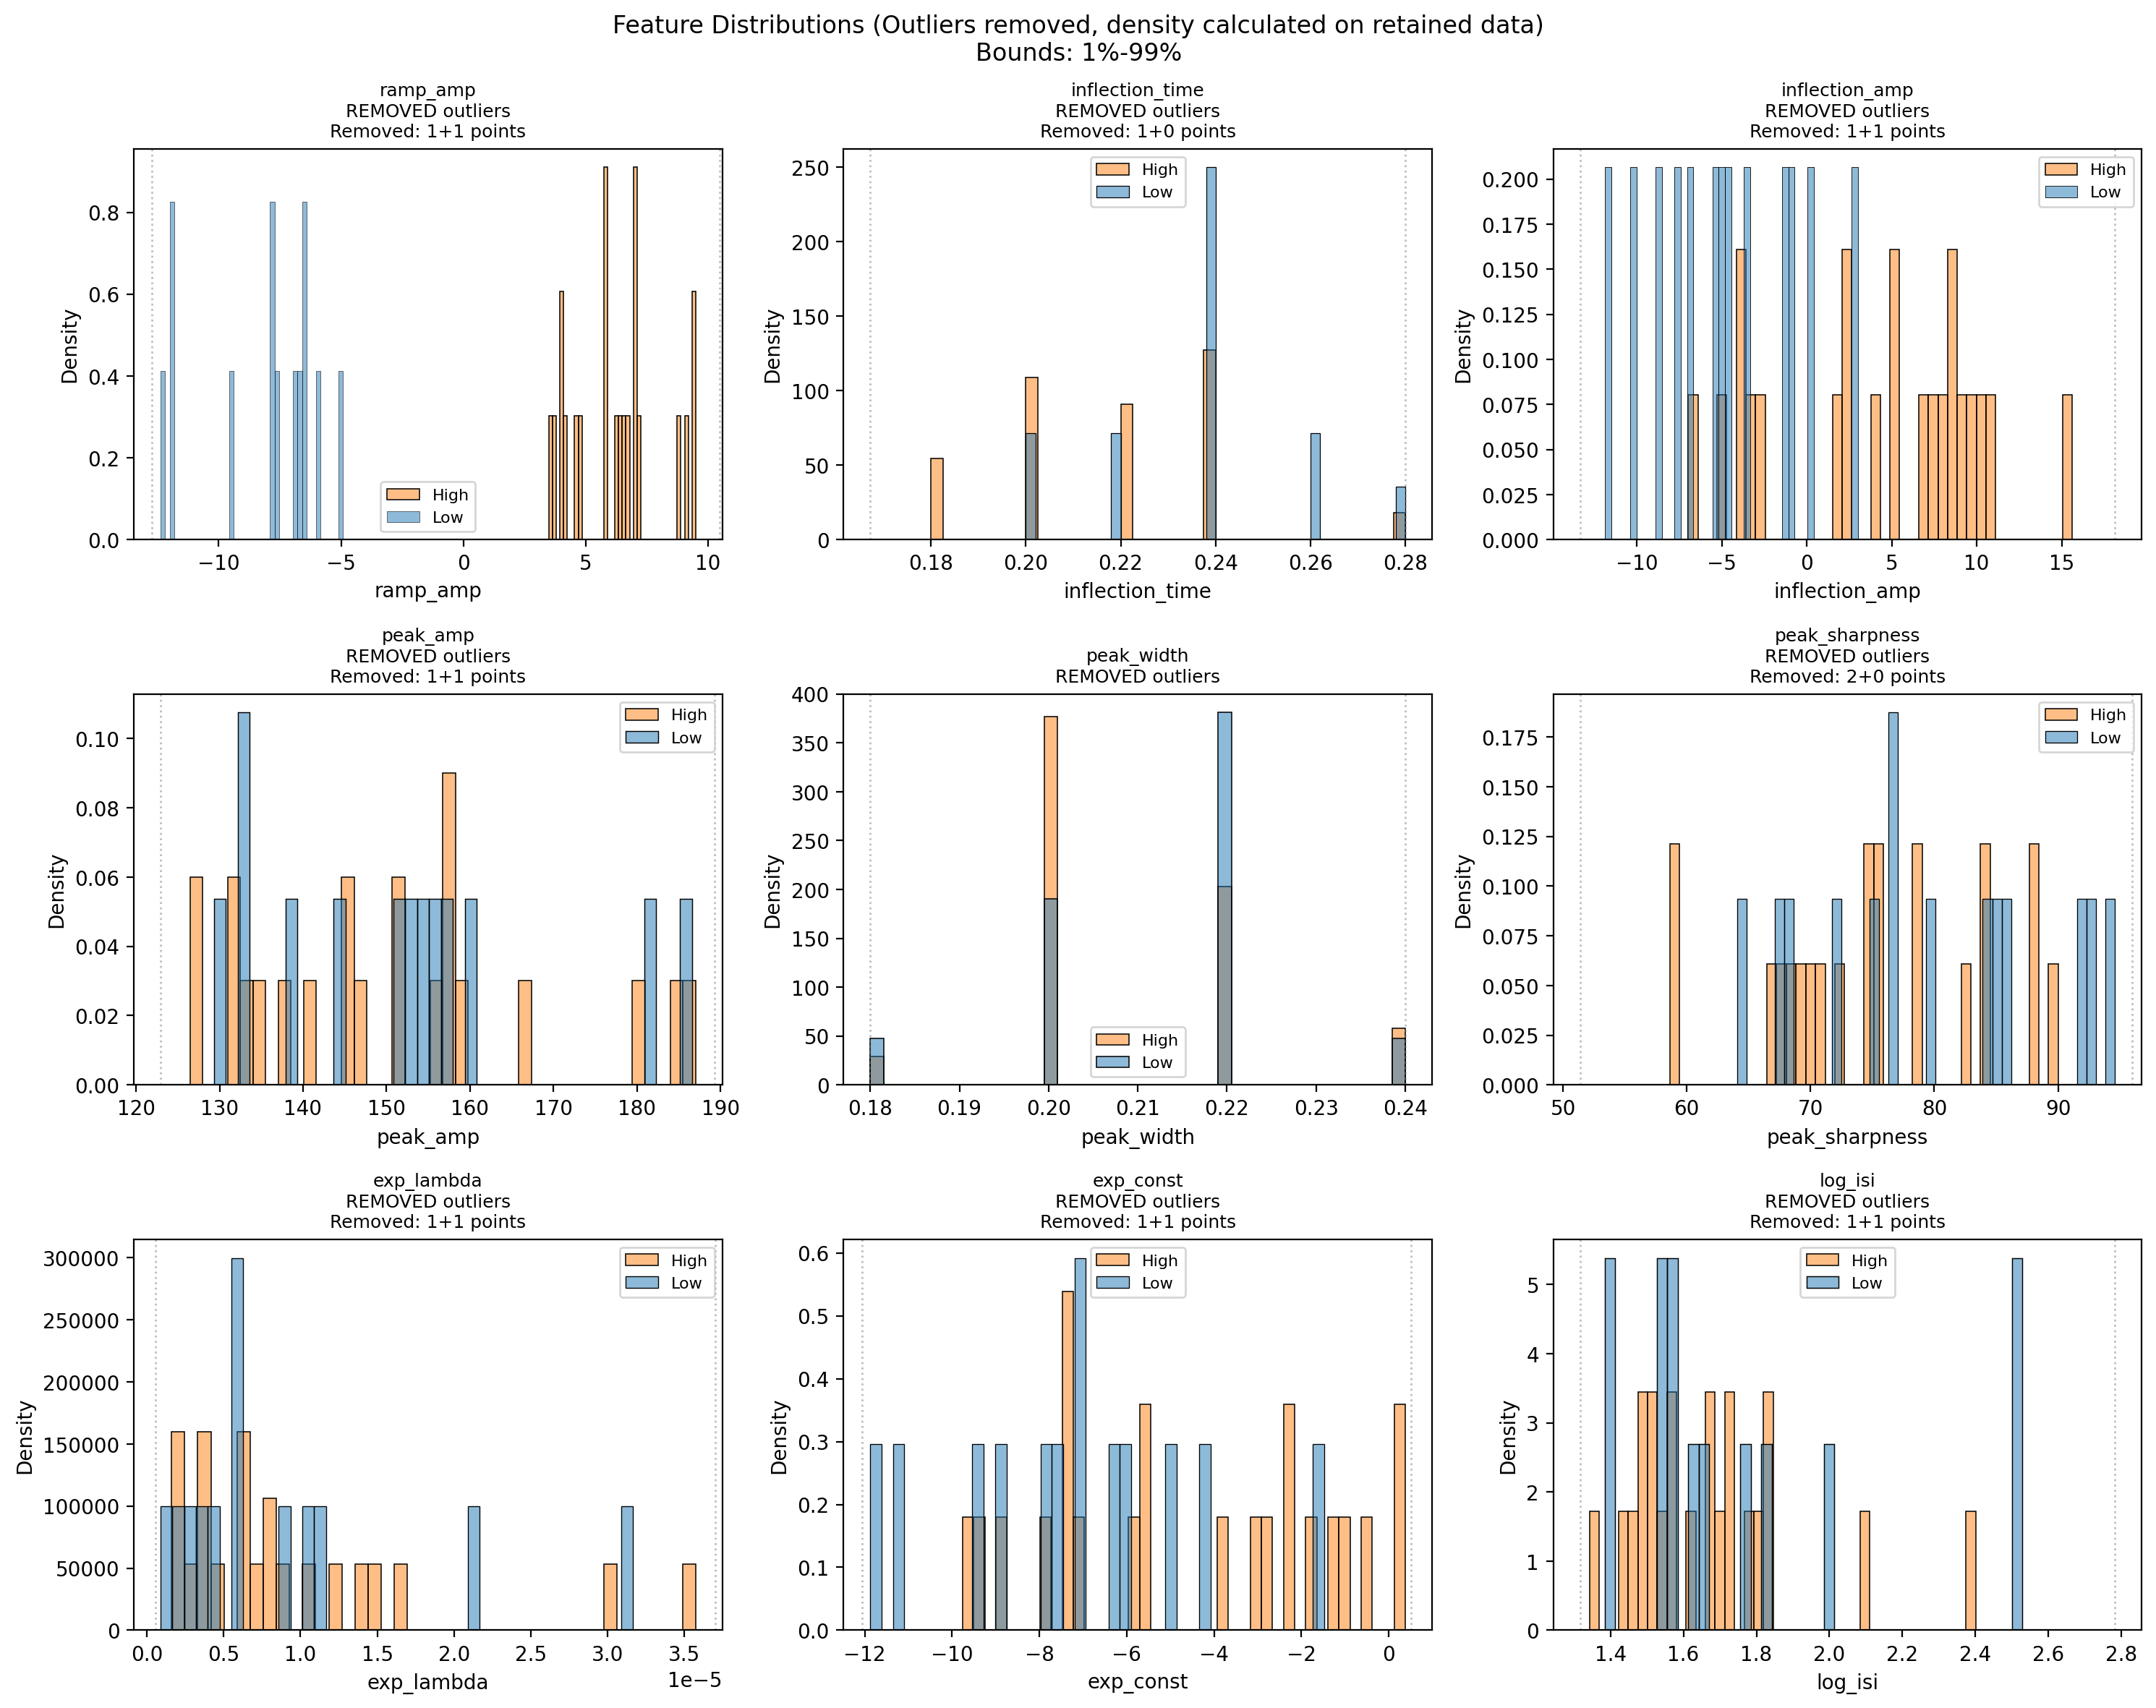

===== DONE =====


===== CLUSTER REPORT: exp_const_cluster =====
→ Plotting spike waveforms by cluster
→ Plotting cluster proportions over time


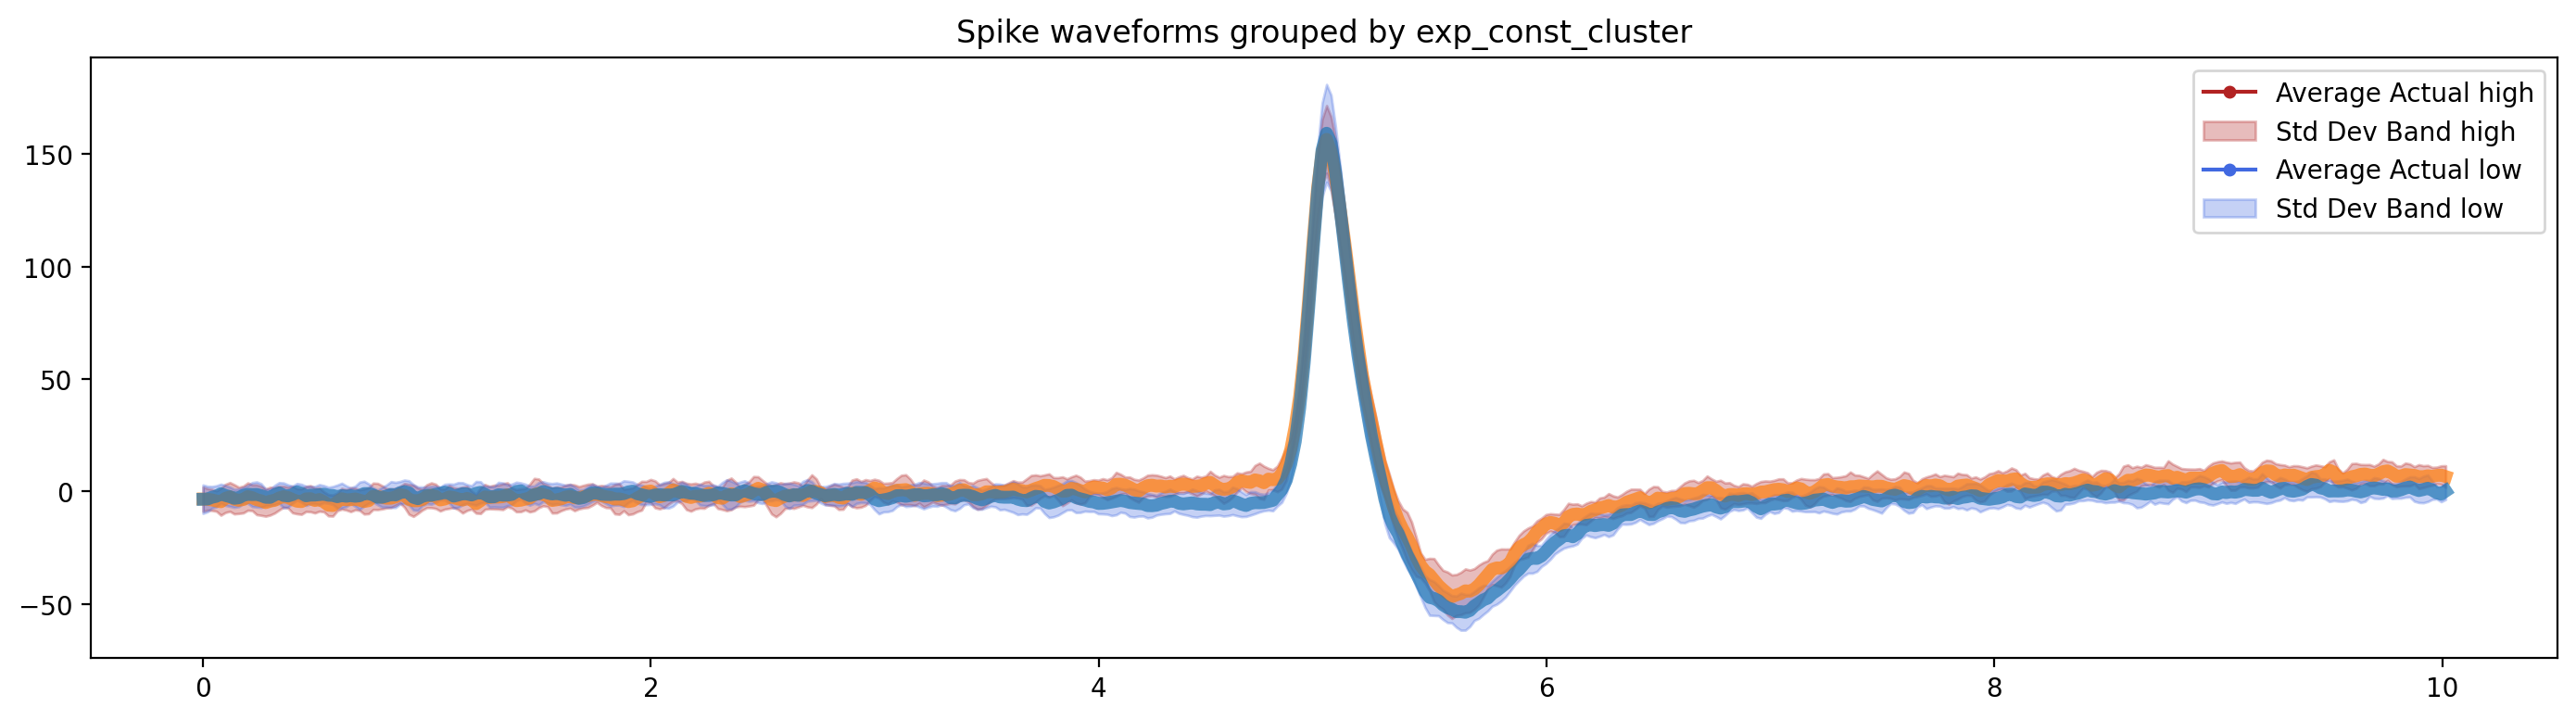

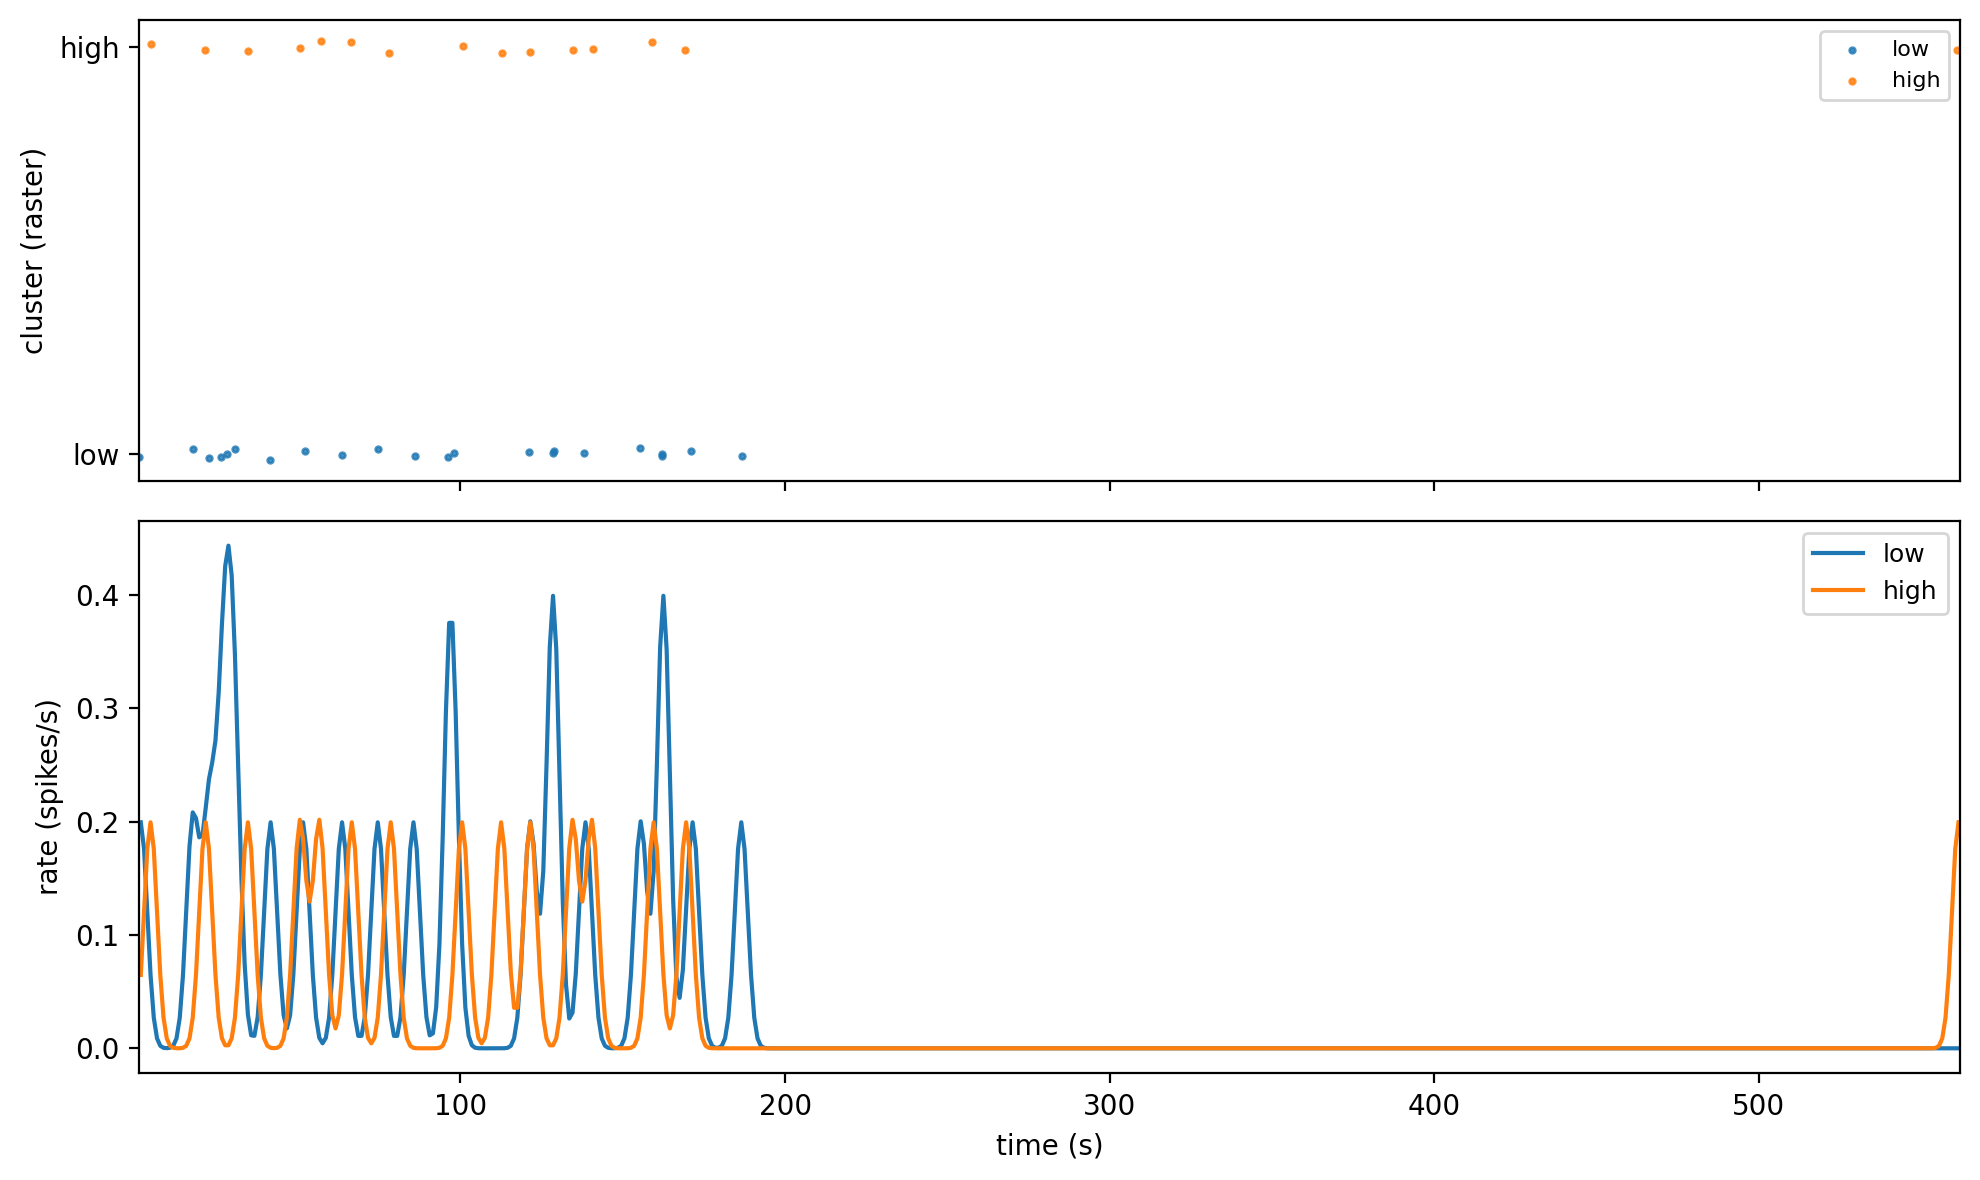

→ Computing cluster transition matrix


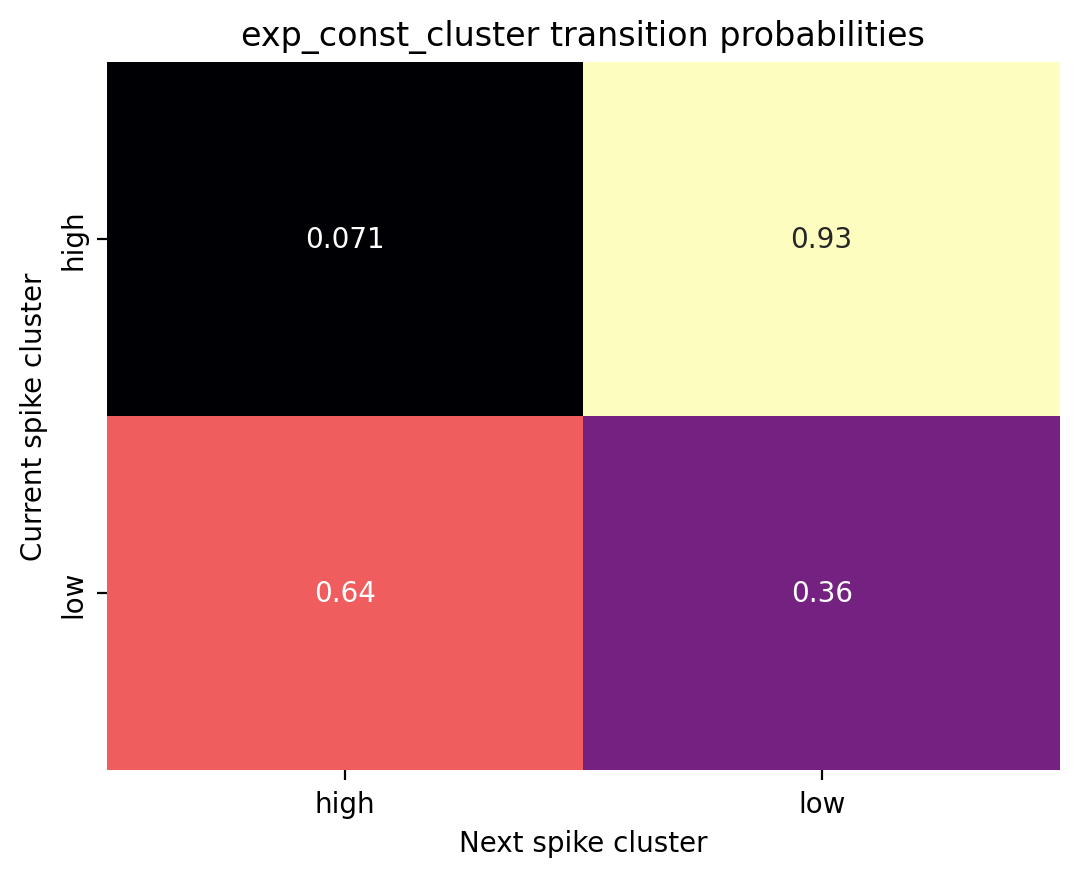

→ Visualizing high vs low feature distributions


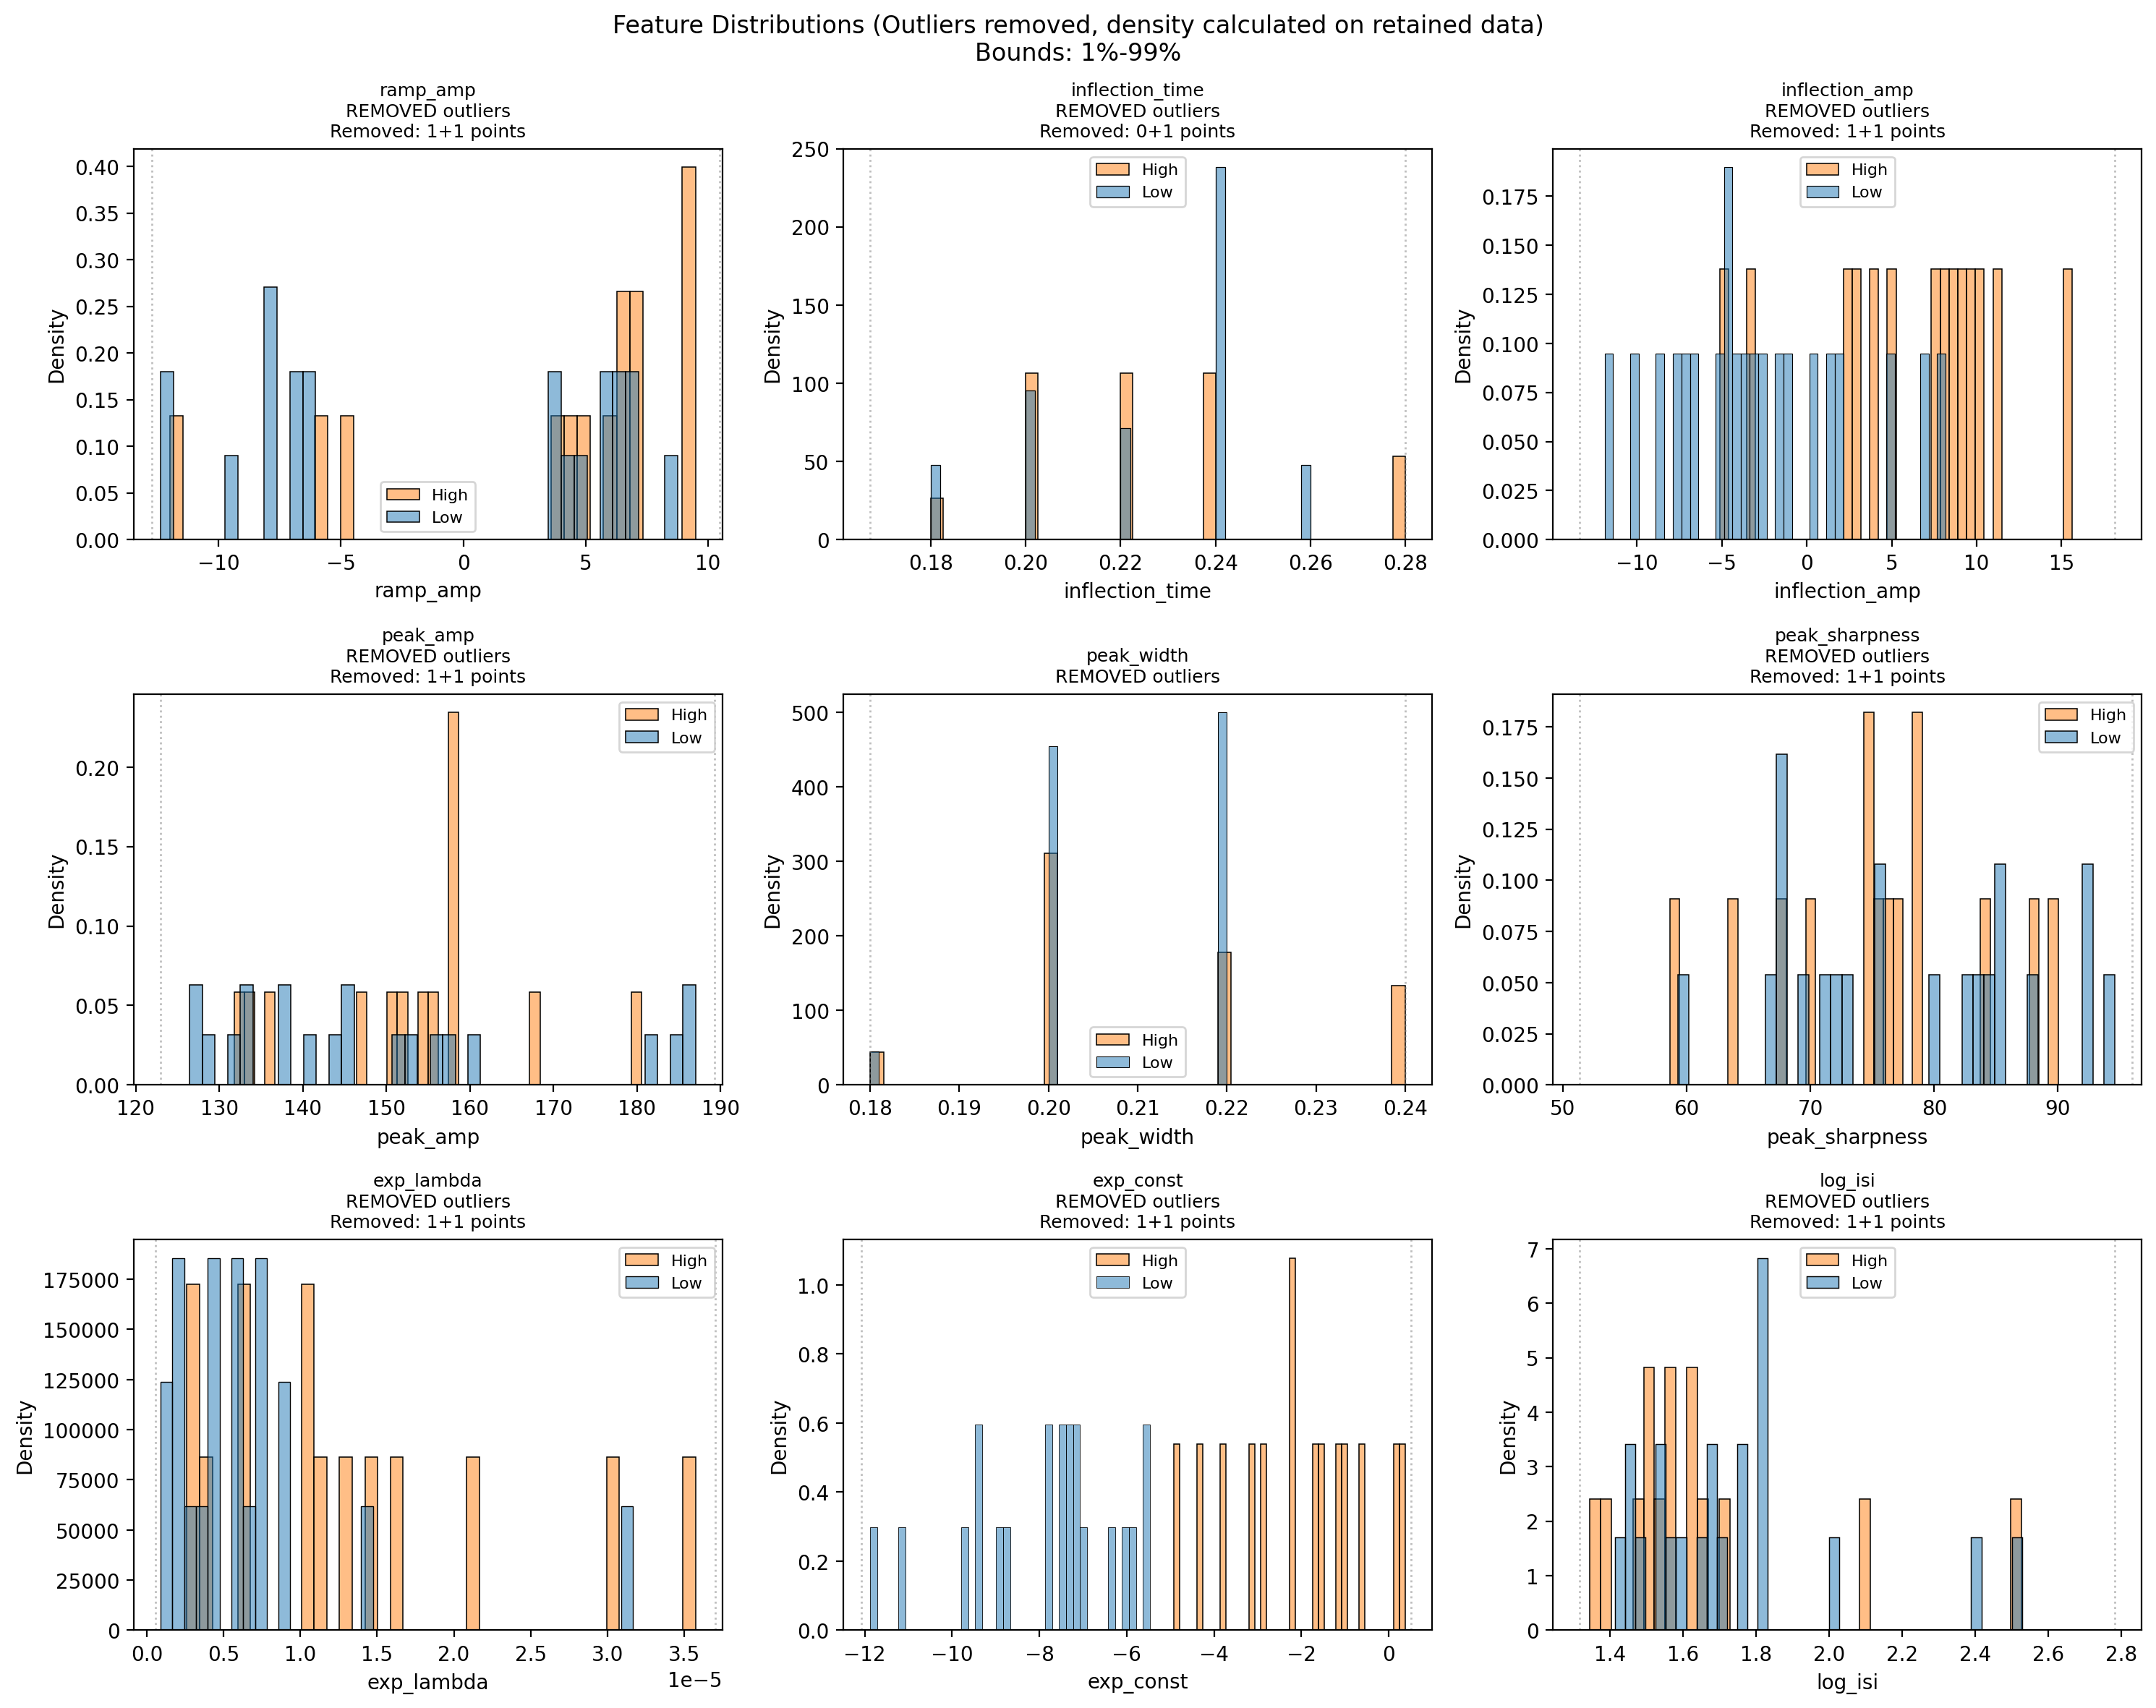

===== DONE =====



In [40]:
for col in df_features_clust.columns:
    if col.endswith("_cluster"):
        plot_full_cluster_report(df_features_clust, sp, col)



## Step 3: LFP analysis

In [41]:
# Extract LFP windows for ALL spikes (no condition)
all_spike_extractor = extract_lfp_windows(
    spk_df=df_features_clust,
    lfp_times_ms=lfp_times,
    lfp_signal=lfp_filt,
    pre_s=1.0,
    post_s=1.5,
    condition=None
)

windows_all      = all_spike_extractor["windows"]
t_rel_all        = all_spike_extractor["times_rel_ms"]
spike_times_all  = all_spike_extractor["spike_times_ms"]
next_spk_all     = all_spike_extractor["next_spike_times_ms"]
meta_df_all      = all_spike_extractor["meta_df"]

In [45]:
"""specparam_by_spike = run_time_resolved_specparam_per_spike(
    lfp_windows=windows_all,
    times_rel_list=t_rel_all,
    next_rel_list=next_spk_all,
    fs=lfp_fs,
    inner_window_sec=0.5,
    freq_range=(4, 90),
    n_freqs=256,
    time_bandwidth=2.0,
    decim_factor=10,
    aperiodic_mode="fixed")"""

'specparam_by_spike = run_time_resolved_specparam_per_spike(\n    lfp_windows=windows_all,\n    times_rel_list=t_rel_all,\n    next_rel_list=next_spk_all,\n    fs=lfp_fs,\n    inner_window_sec=0.5,\n    freq_range=(4, 90),\n    n_freqs=256,\n    time_bandwidth=2.0,\n    decim_factor=10,\n    aperiodic_mode="fixed")'

In [46]:
"""
#save as pickle
with open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/multitaper_pickles/c45/specp_epochs.pkl', 'wb') as file:
    pickle.dump(specparam_by_spike, file)"""

"\n#save as pickle\nwith open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/multitaper_pickles/c45/specp_epochs.pkl', 'wb') as file:\n    pickle.dump(specparam_by_spike, file)"

In [47]:
#open pickle
with open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/multitaper_pickles/c45/specp_epochs.pkl', 'rb') as file:
    specparam_by_spike = pickle.load(file)
    

In [48]:
specparam_by_spike = trim_edges(specparam_by_spike, edge_sec=0.5)

#### Analyze by group

In [49]:
groups = build_lfp_groups_from_clusters(df_features_clust
    ,all_spike_extractor)

#### LFP signal

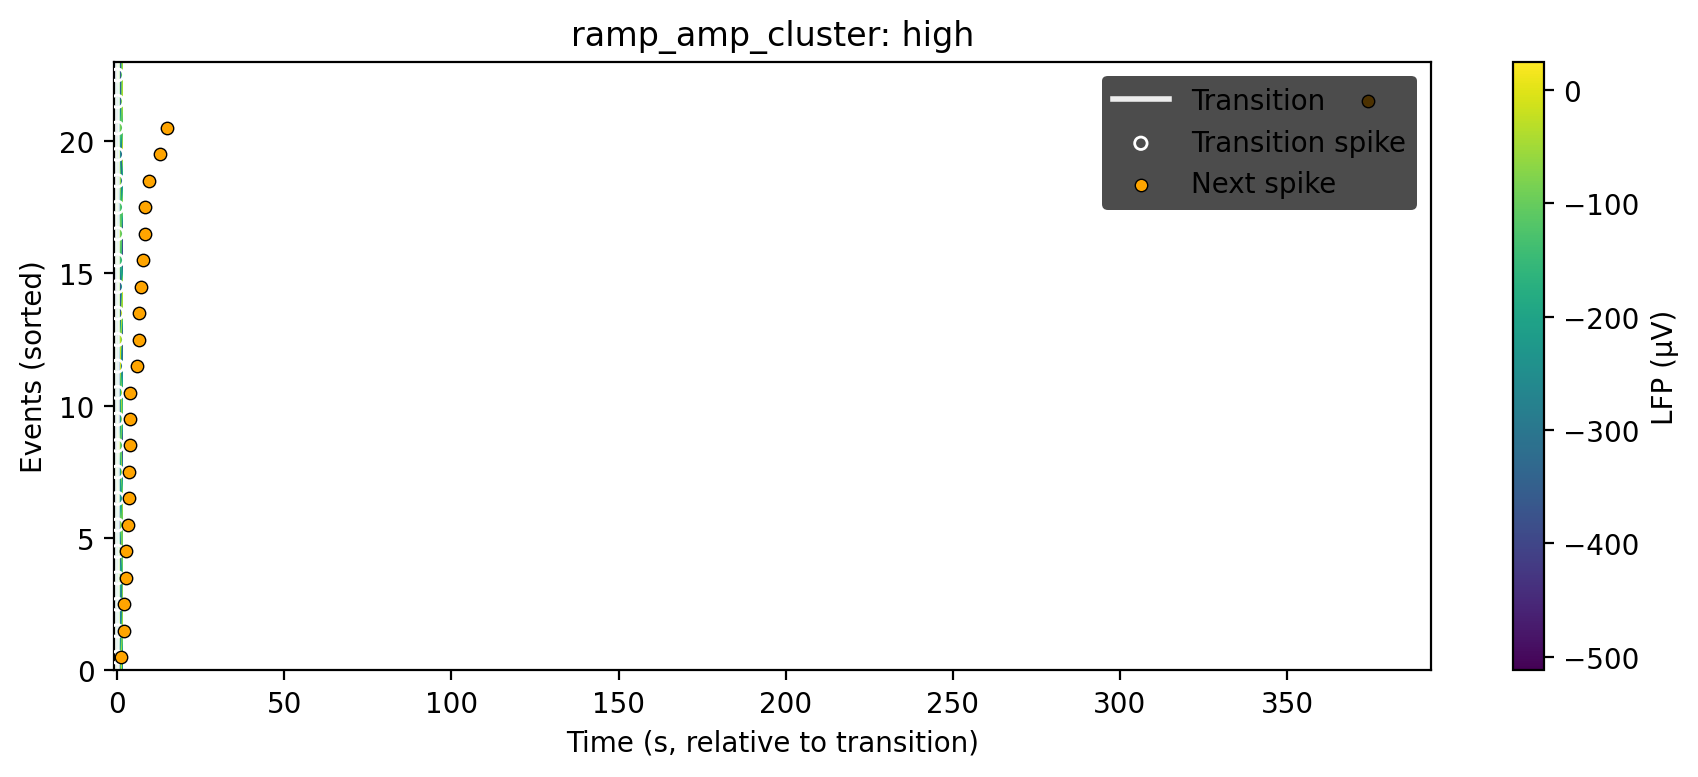

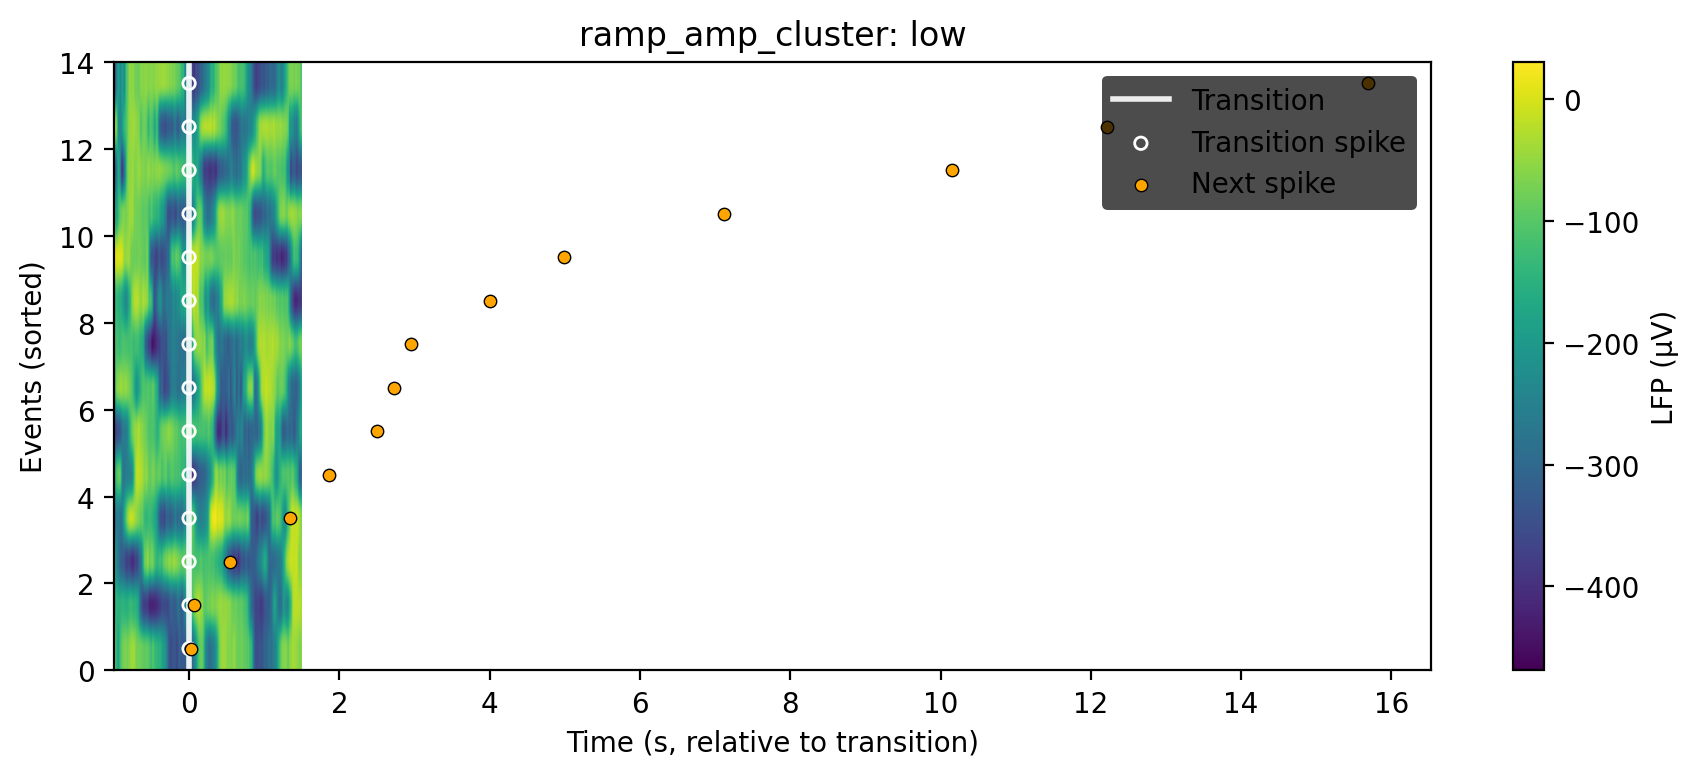

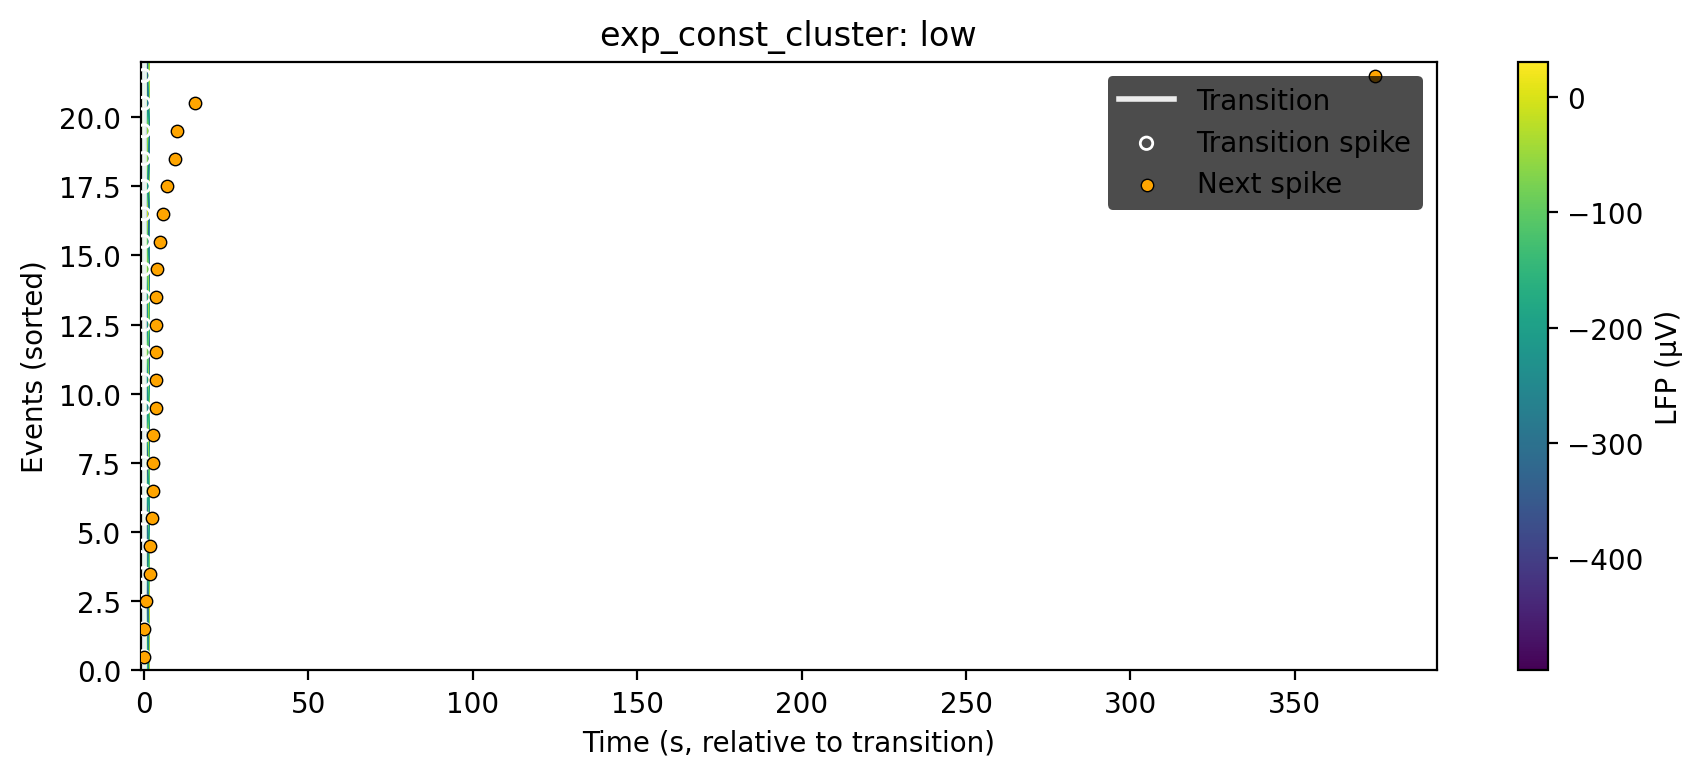

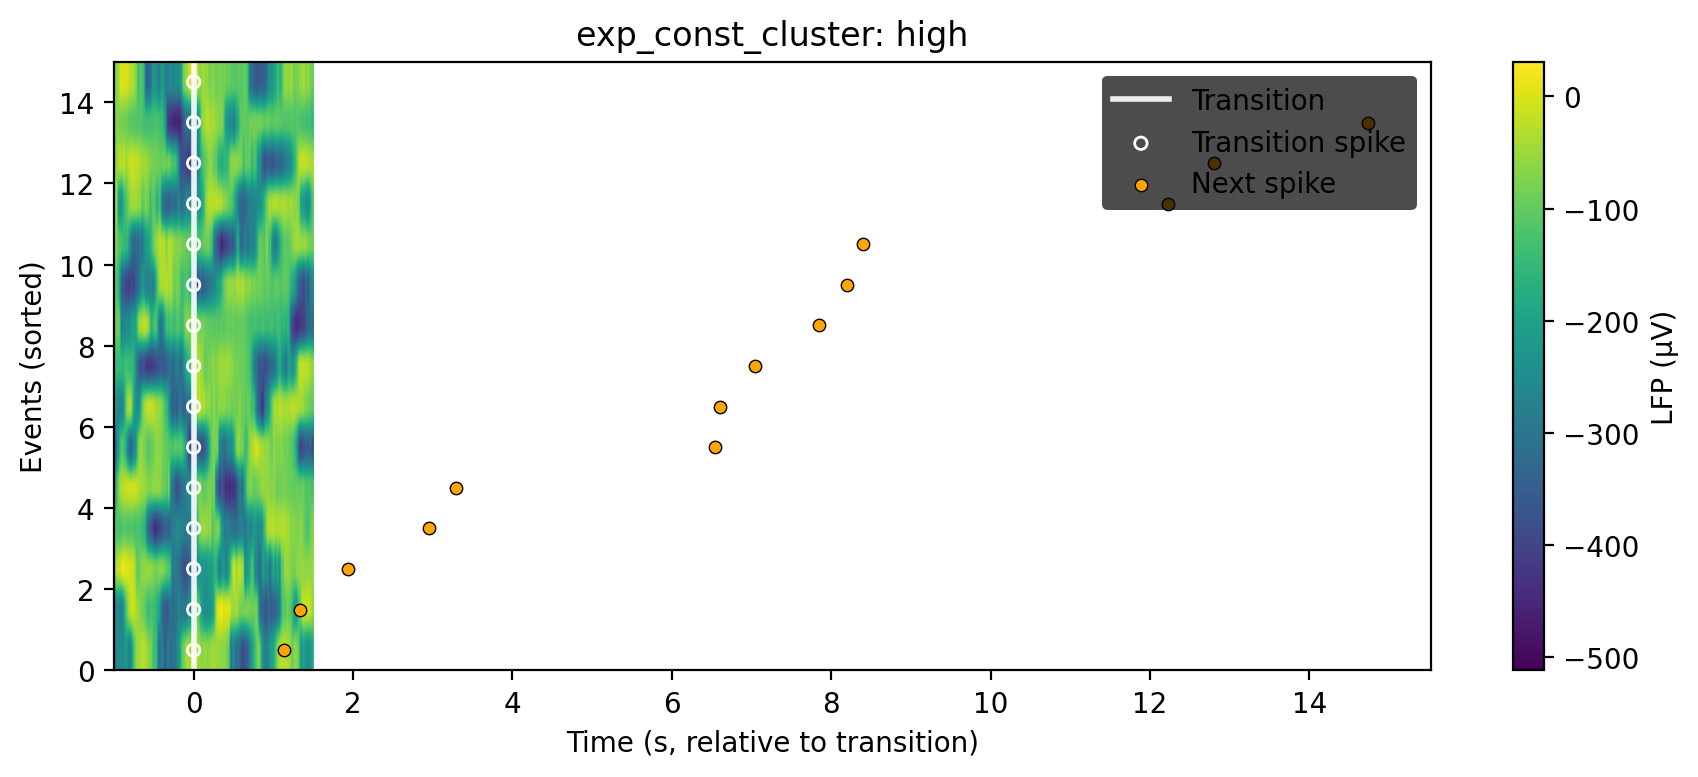

In [50]:
lfp_heatmaps = plot_window_feature_groups_heatmap(
    groups,
    feature_label="LFP (µV)",
    cmap="viridis",
    time_unit="ms",
)


In [51]:
gamma_groups = make_specparam_feature_groups(
    specparam_by_spike, groups, feature="band", band="gamma"
)

exp_groups = make_specparam_feature_groups(
    specparam_by_spike, groups, feature="exponent"
)


#### AUC gamma and aperiodic exponents 

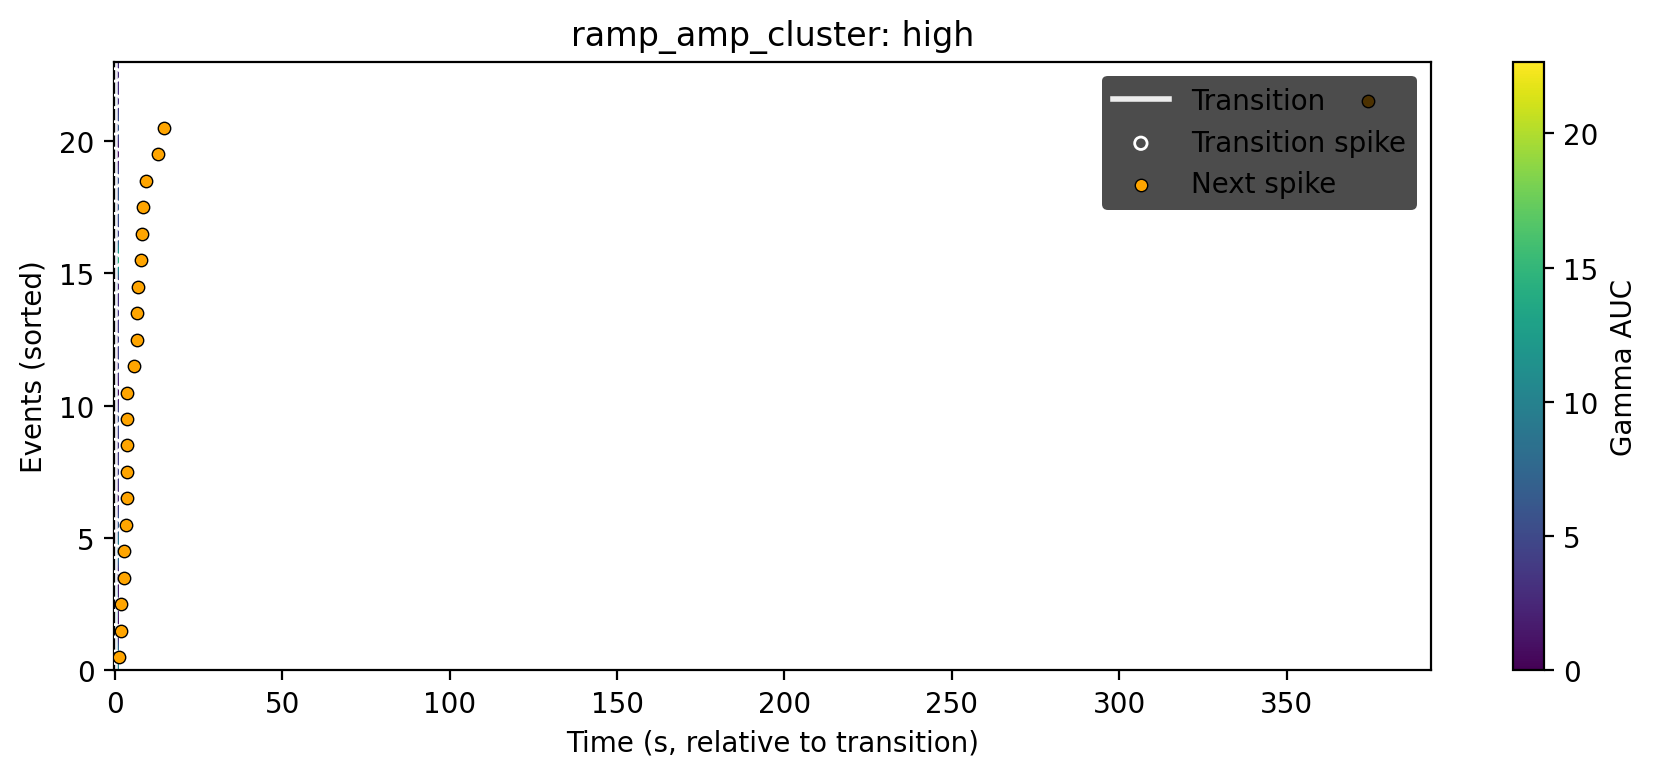

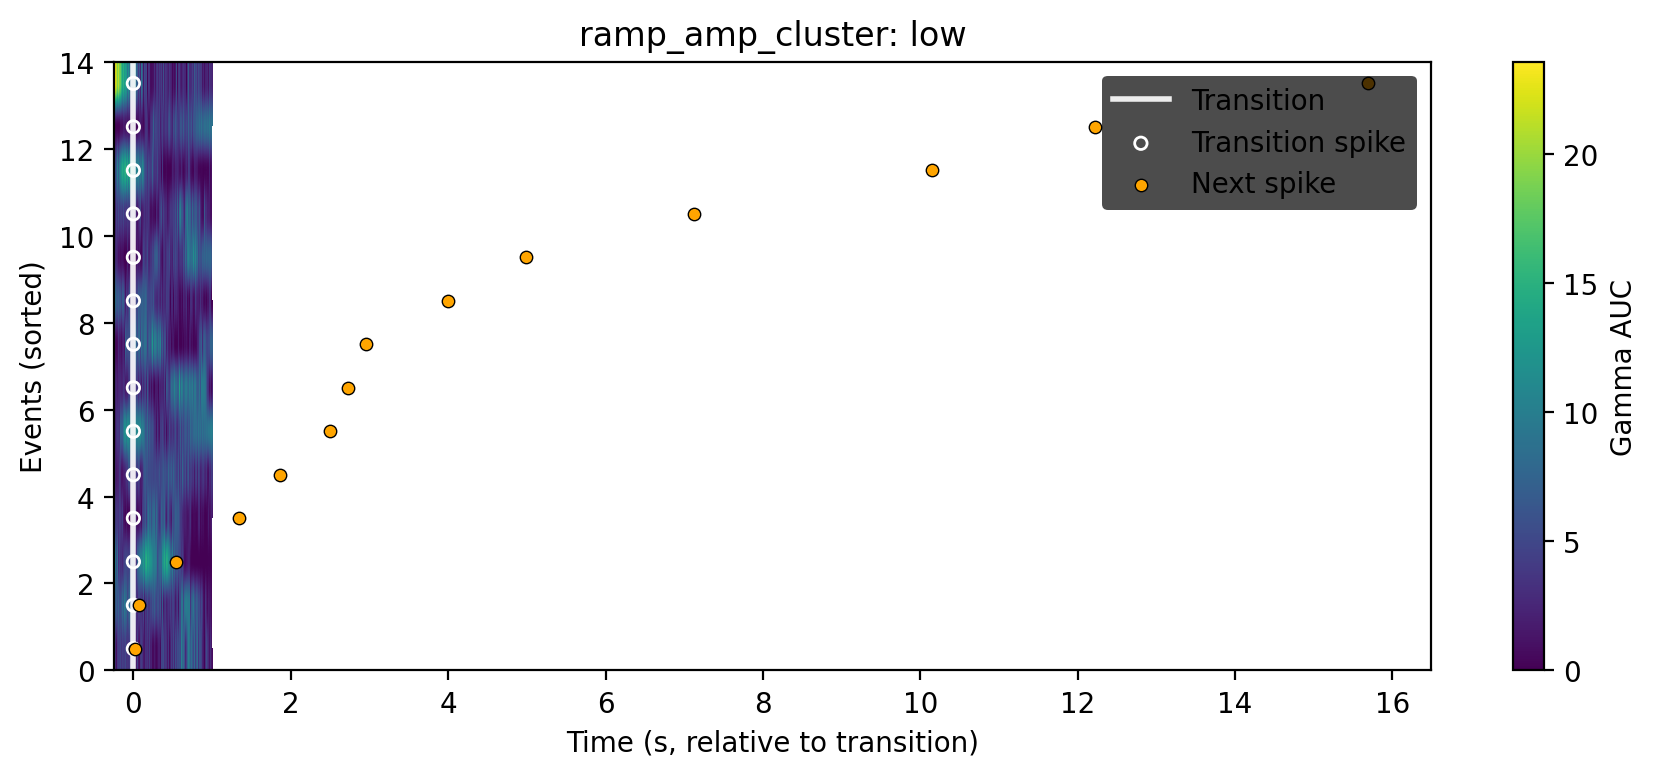

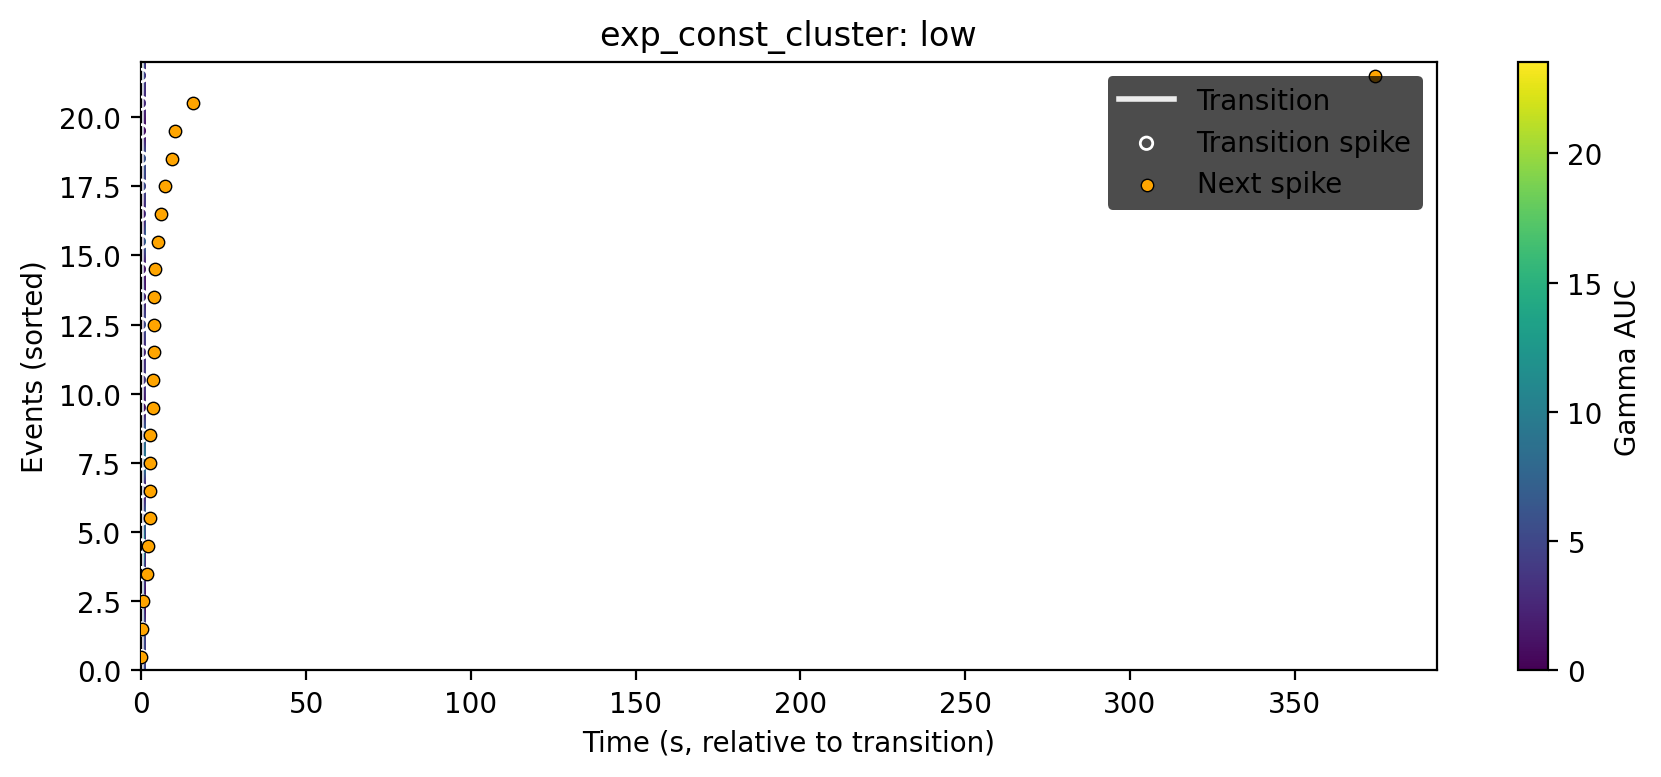

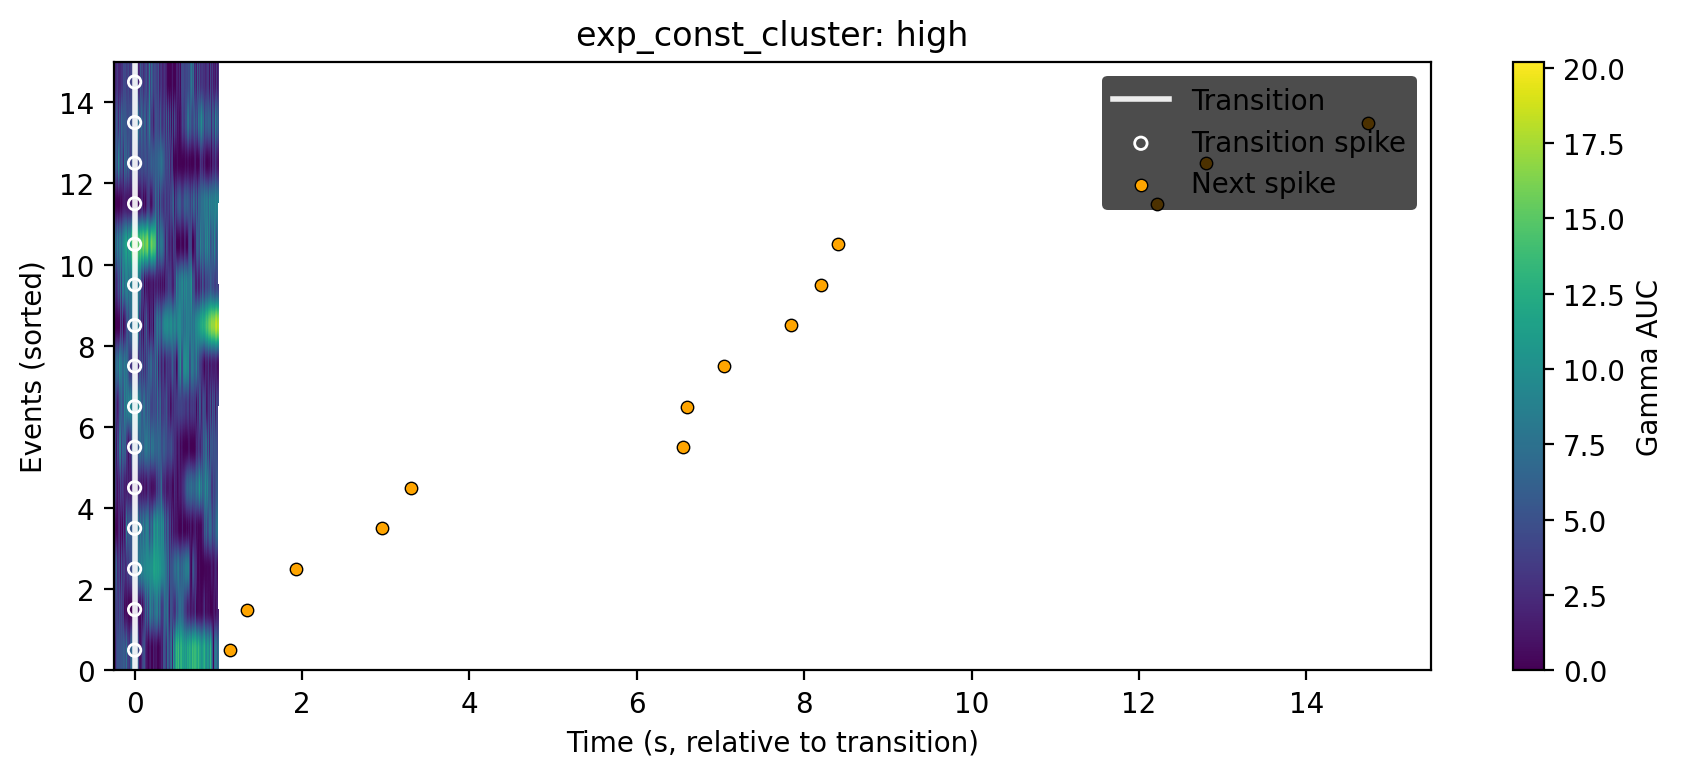

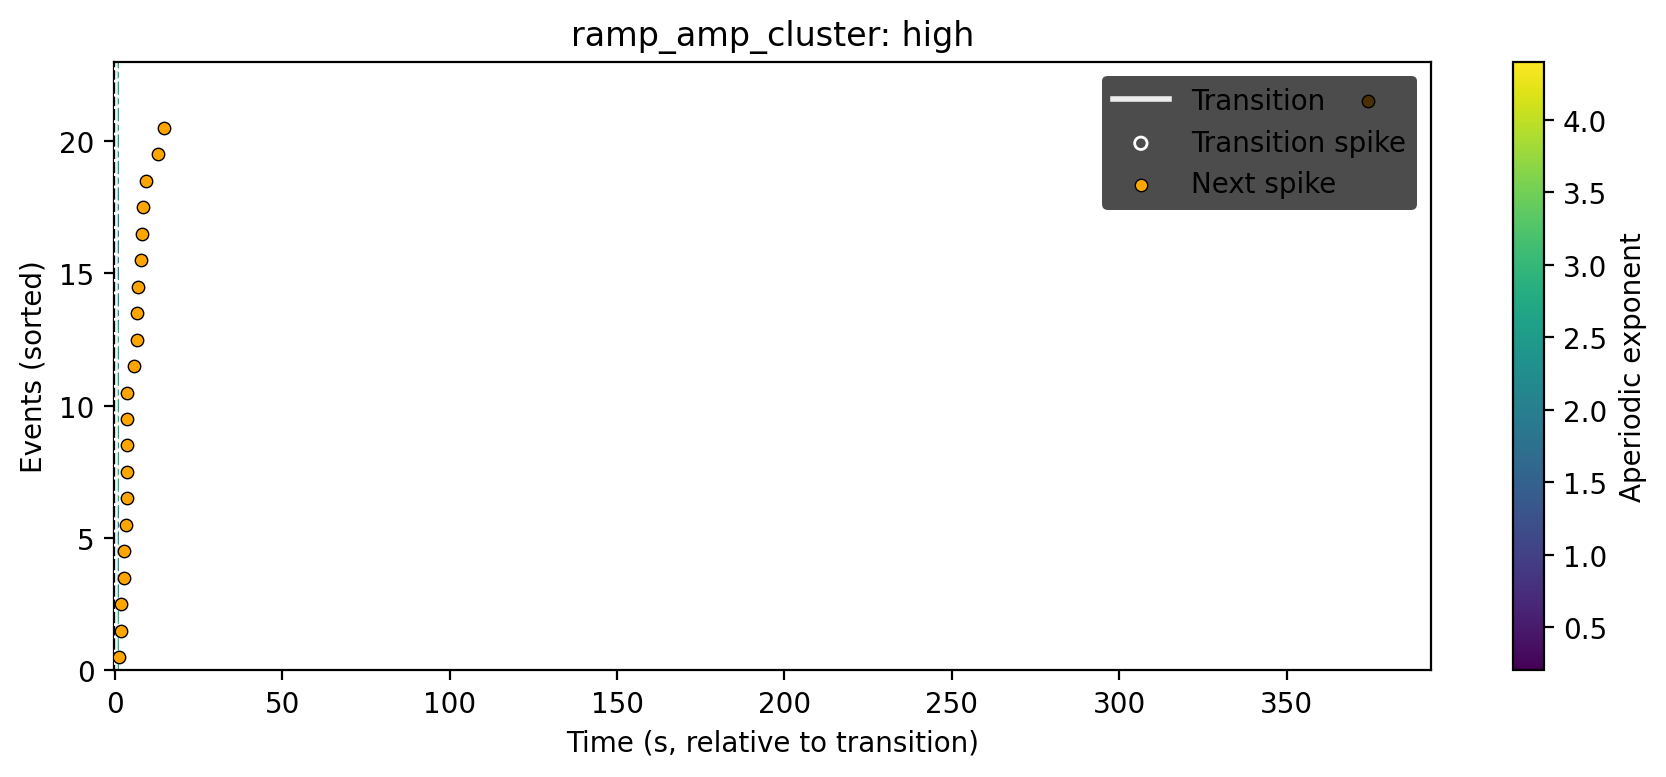

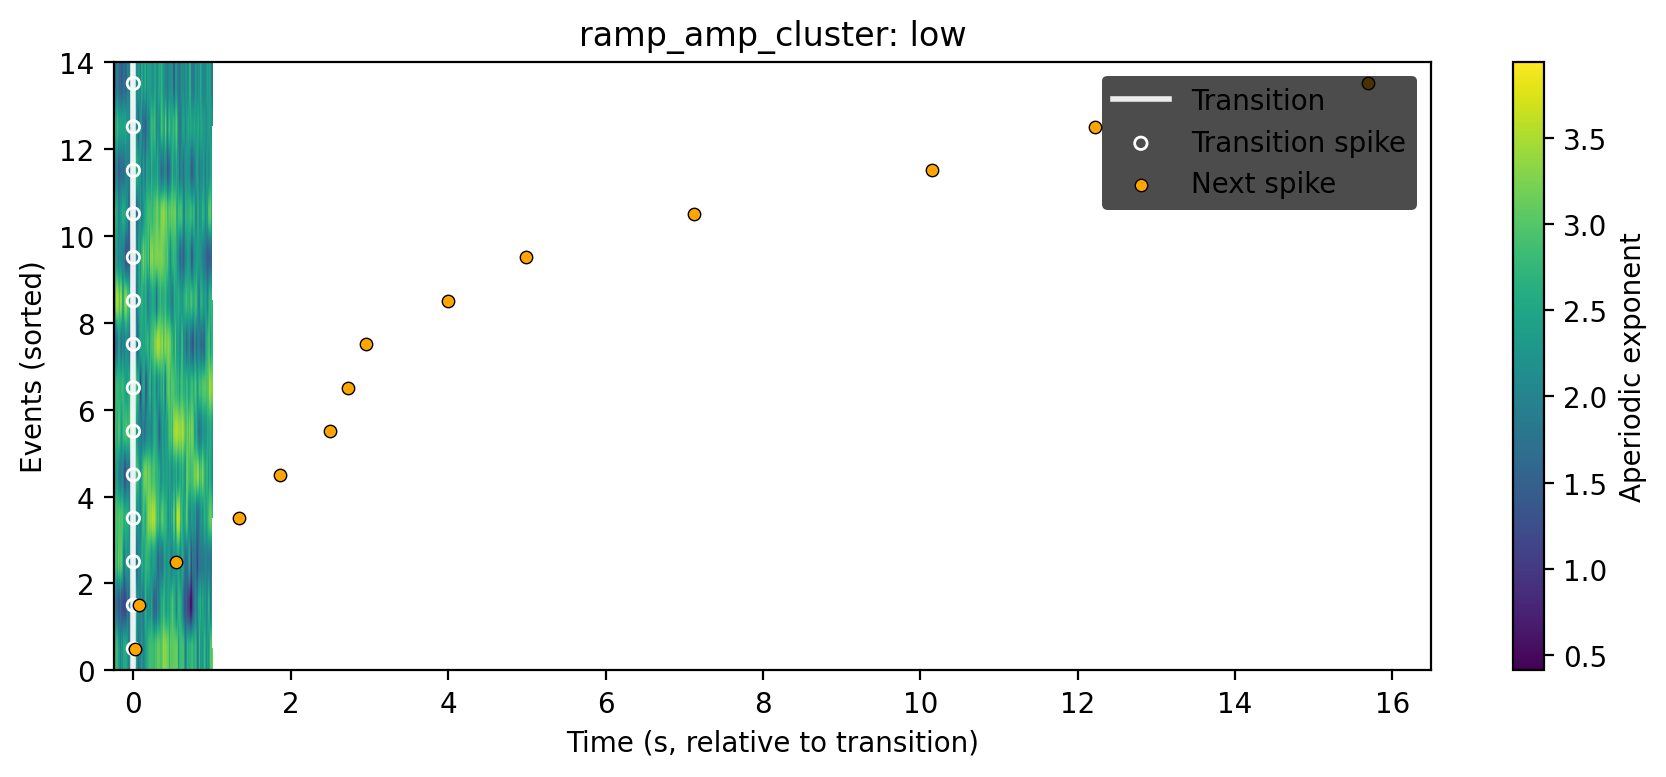

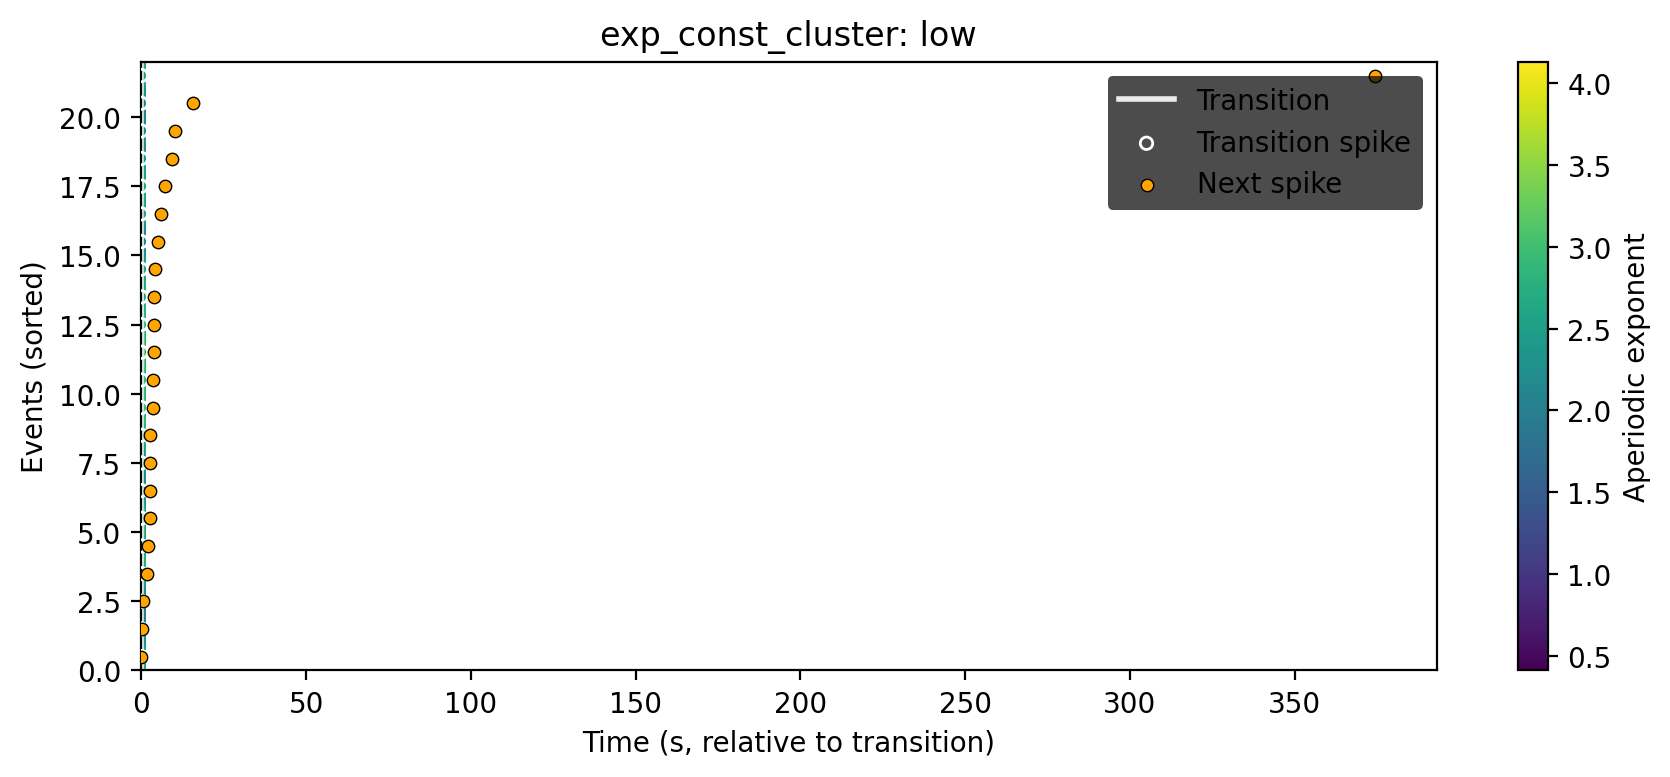

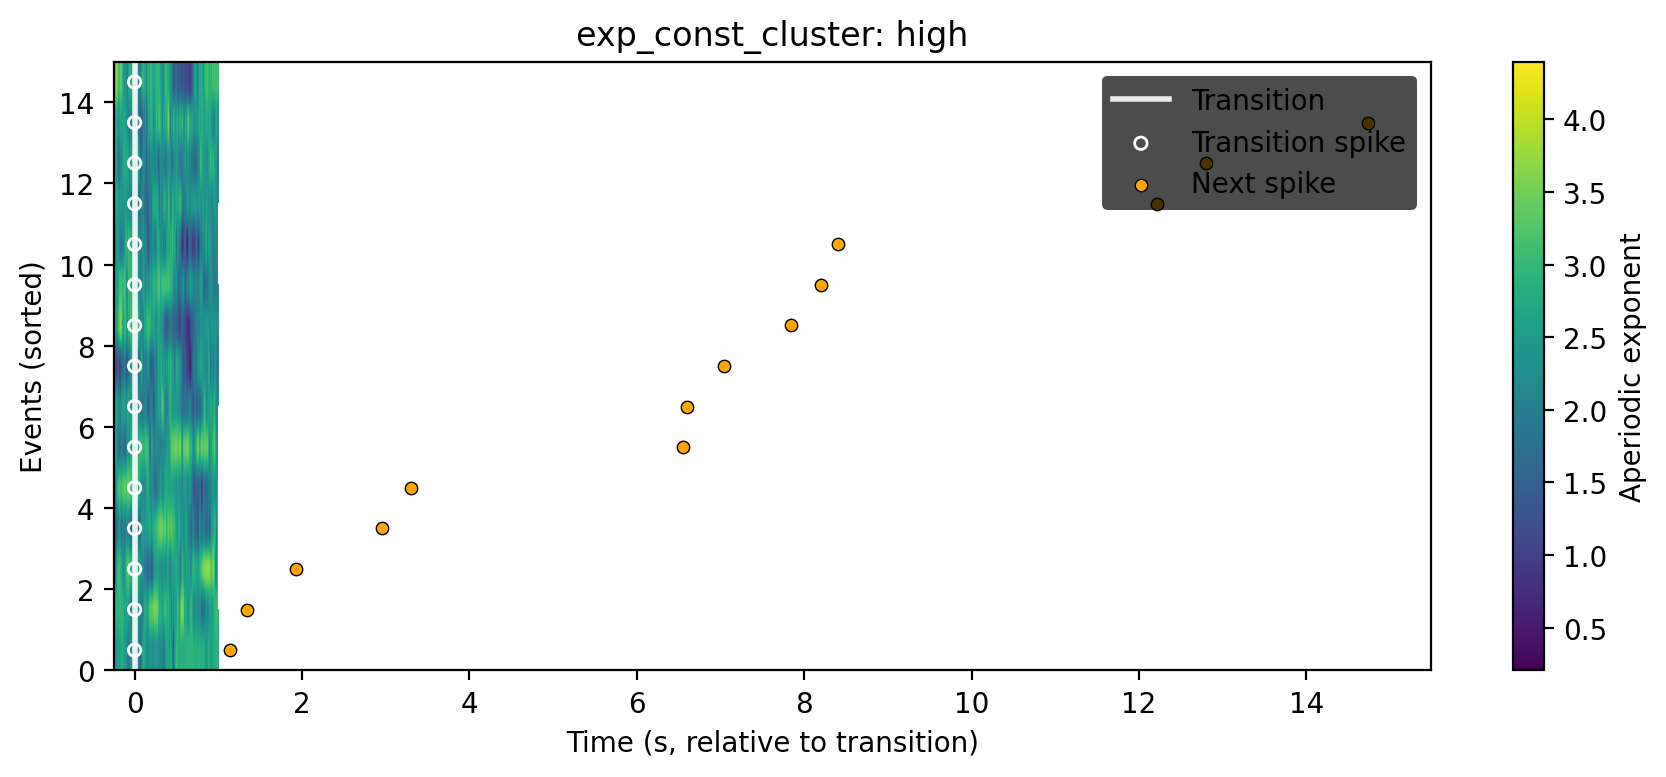

In [52]:
_ = plot_window_feature_groups_heatmap(
    gamma_groups,
    feature_label="Gamma AUC",
    cmap="viridis",
    time_unit="s",   
    sort_by="next_rel",
)

_ = plot_window_feature_groups_heatmap(
    exp_groups,
    feature_label="Aperiodic exponent",
    cmap="viridis",
    time_unit="s",
    sort_by="next_rel",
)

#### AUC gamma and aperiodic exponent traces

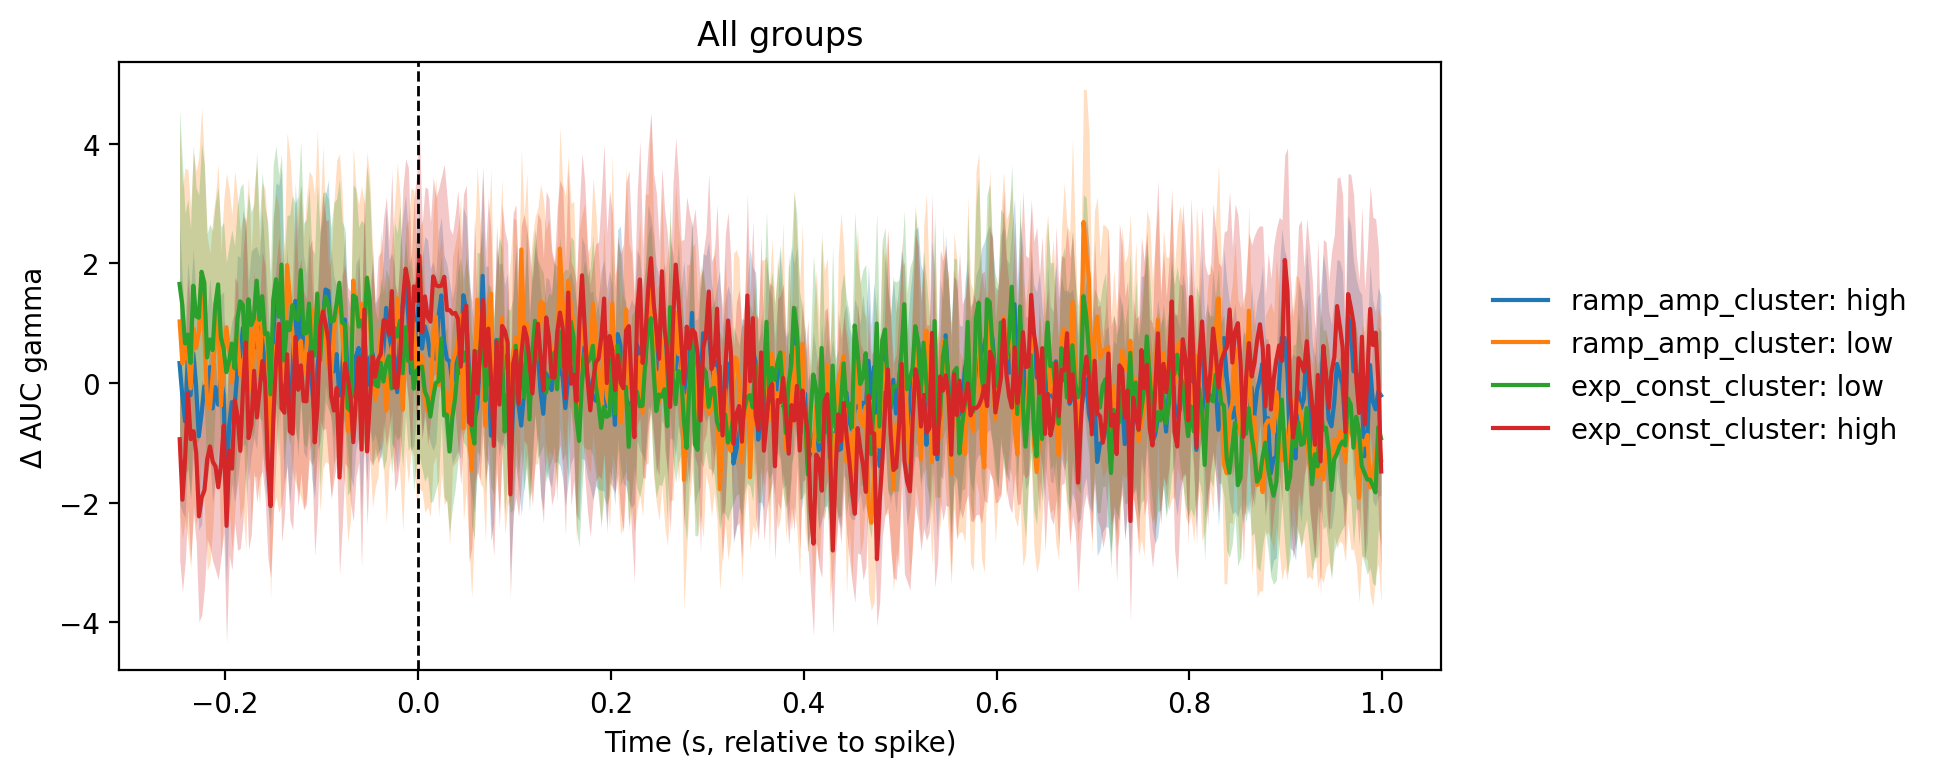

In [53]:
gamma_pre_spike_win = window_feature_group_traces_ci_delta(
    gamma_groups,
    baseline_window=(-0.5, 1),
    time_unit="s",ylabel="Δ AUC gamma",
)


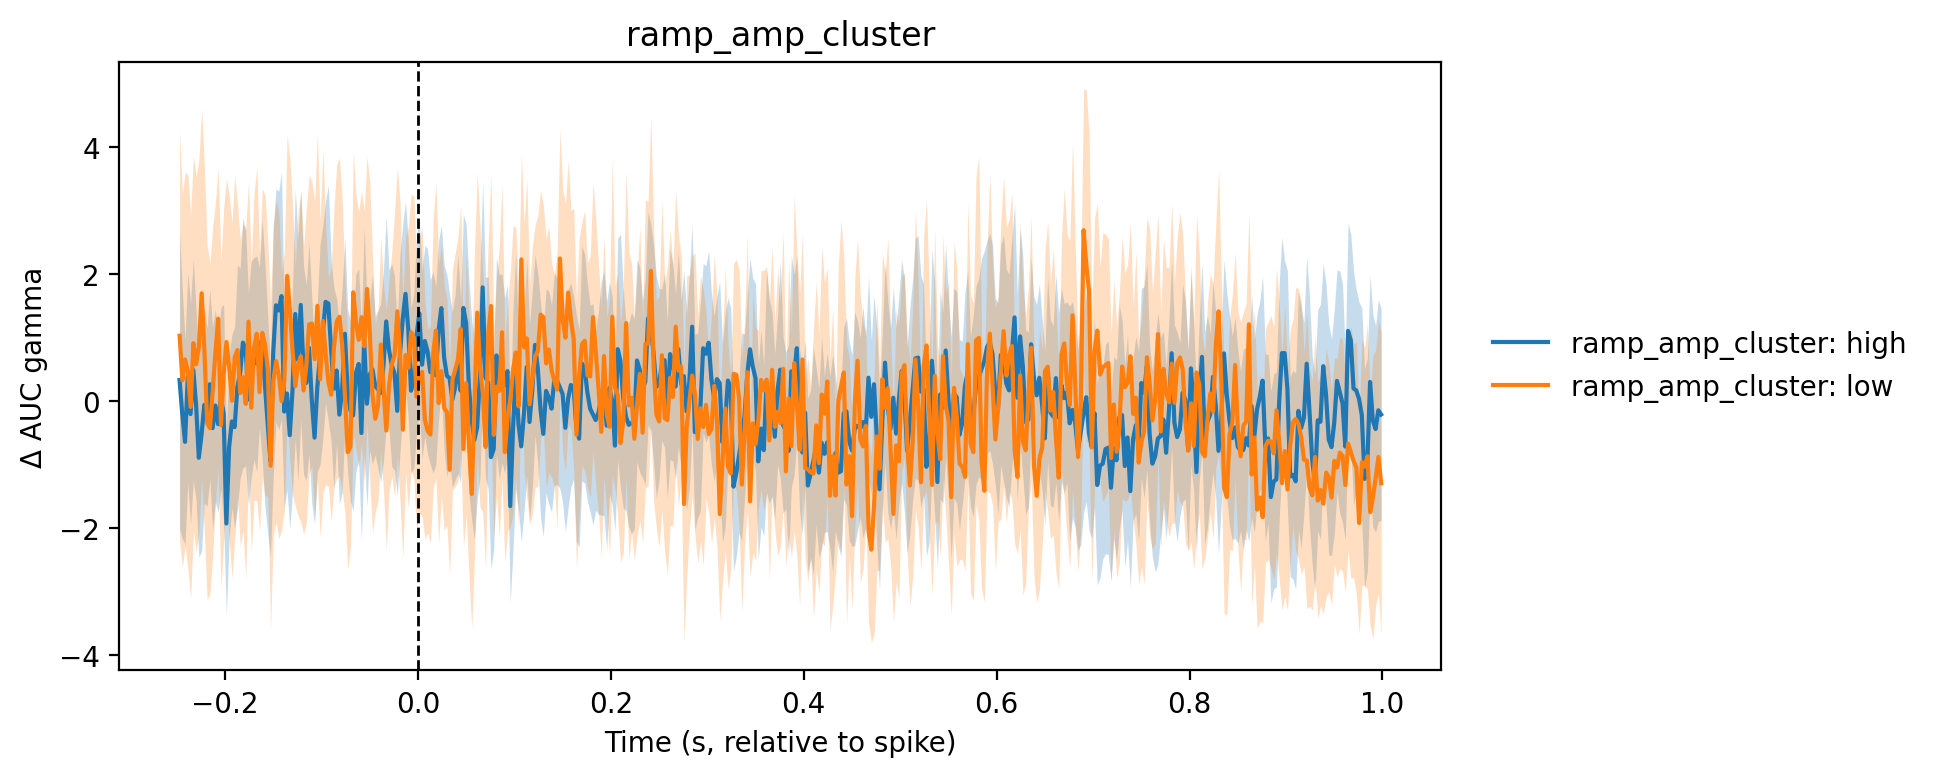

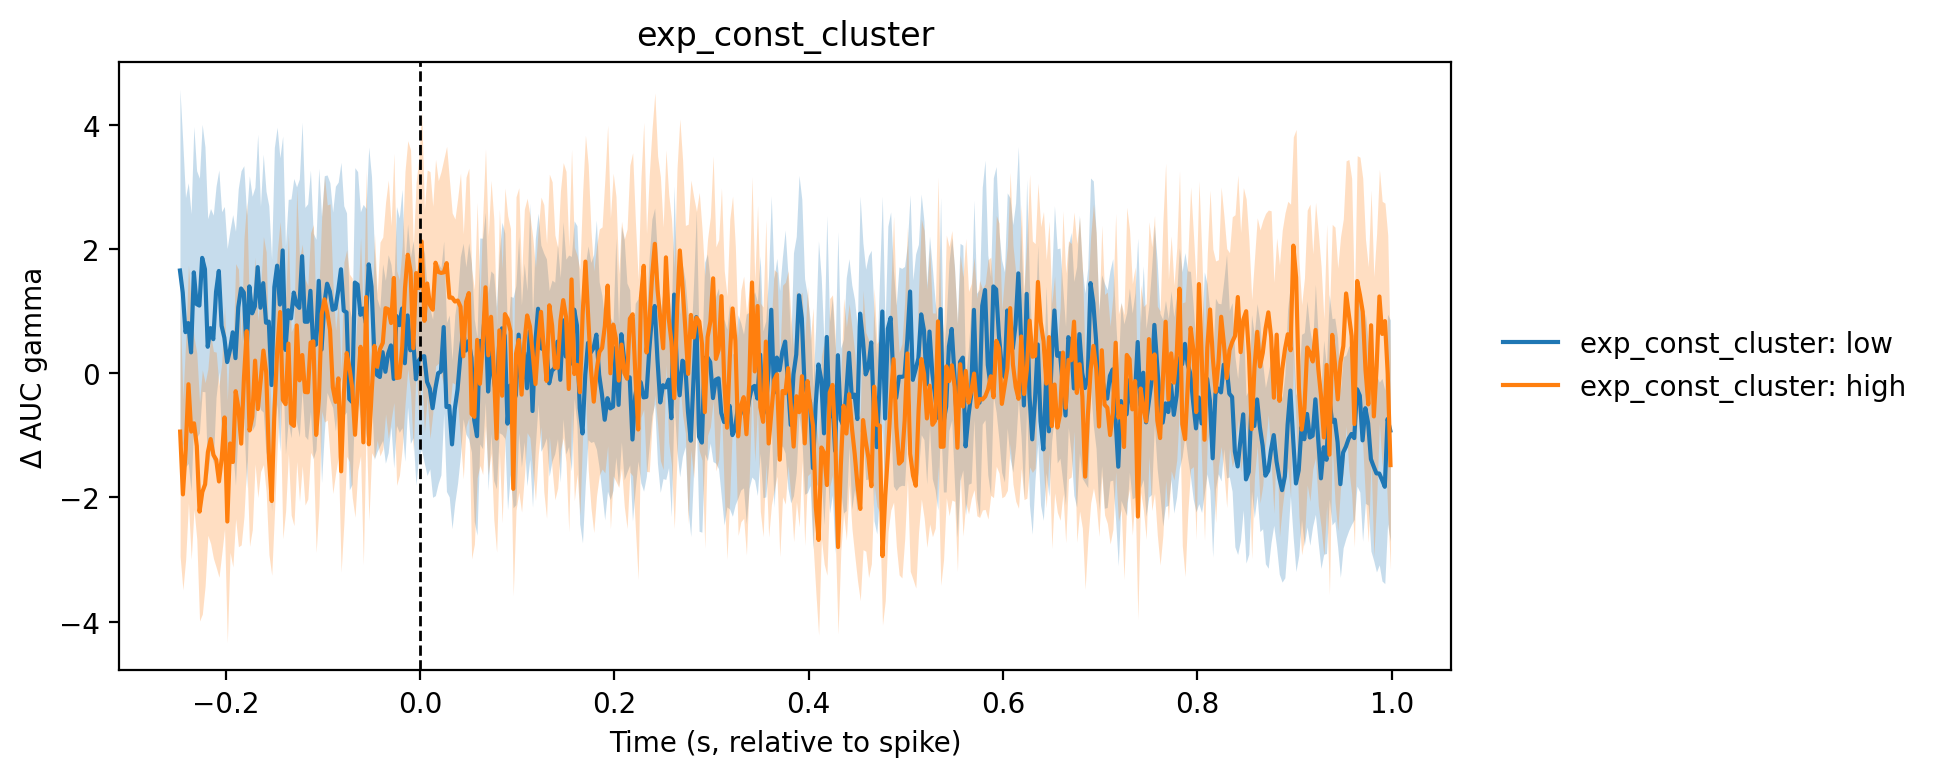

In [54]:
_= window_feature_group_traces_ci_delta(
    gamma_groups,
    baseline_window=(-0.5, 1),
    time_unit="s", plot_mode ="per_cluster",ylabel="Δ AUC gamma",
)


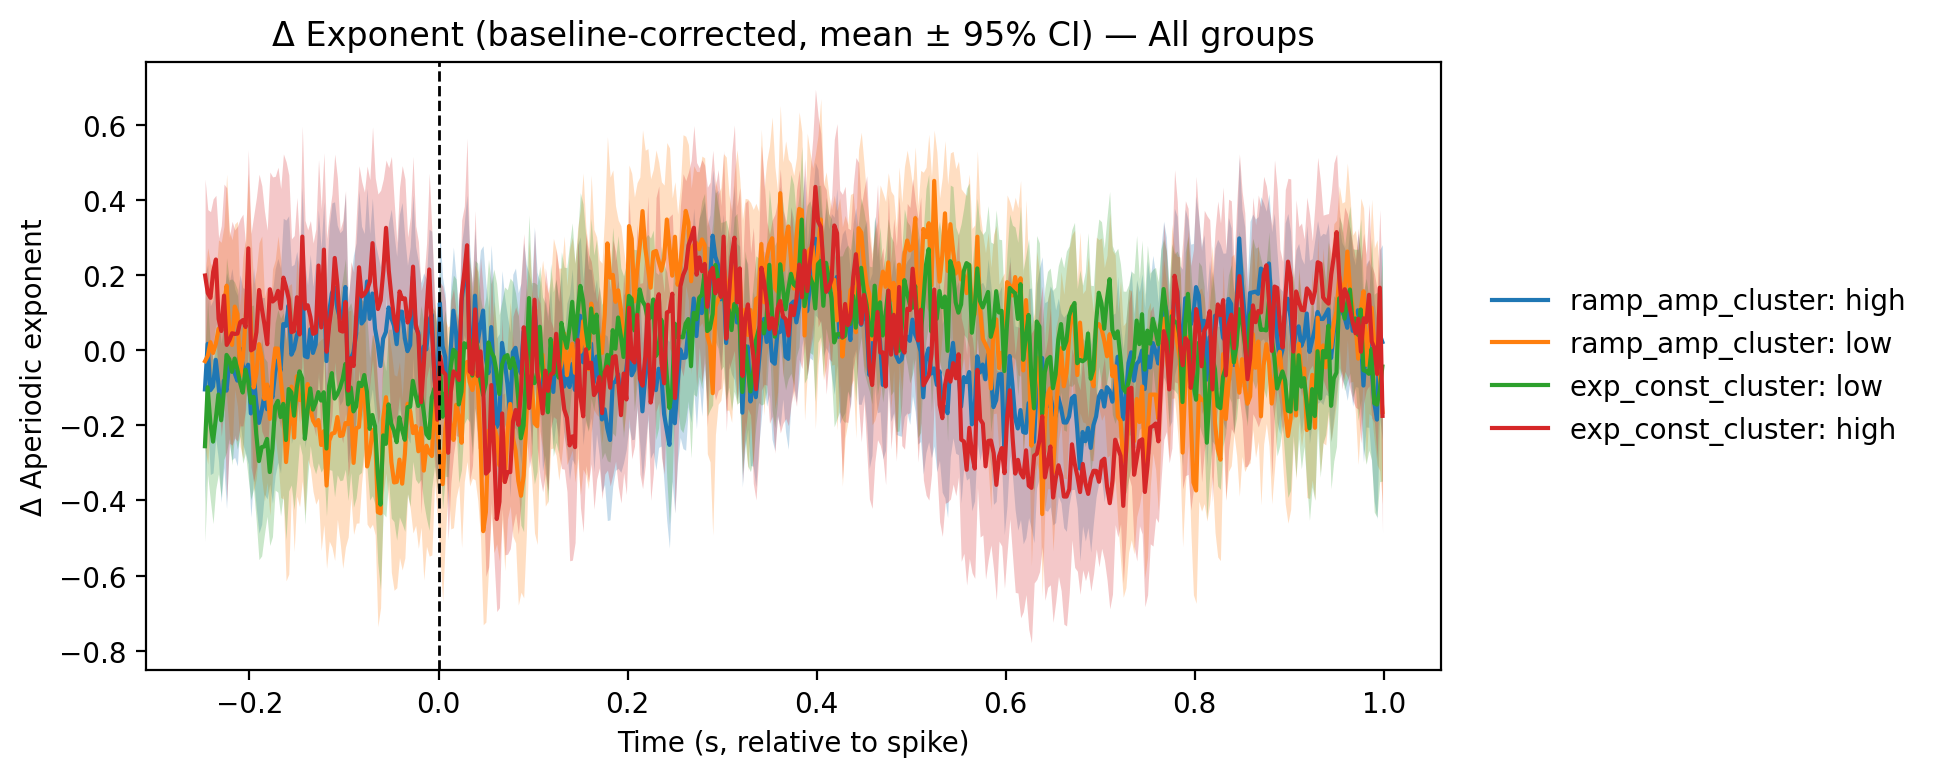

In [55]:
exp_pre_spike_win = window_feature_group_traces_ci_delta(
    exp_groups,
    ylabel="Δ Aperiodic exponent",
    title="Δ Exponent (baseline-corrected, mean ± 95% CI)",
    baseline_window=(-0.5, 1),
)


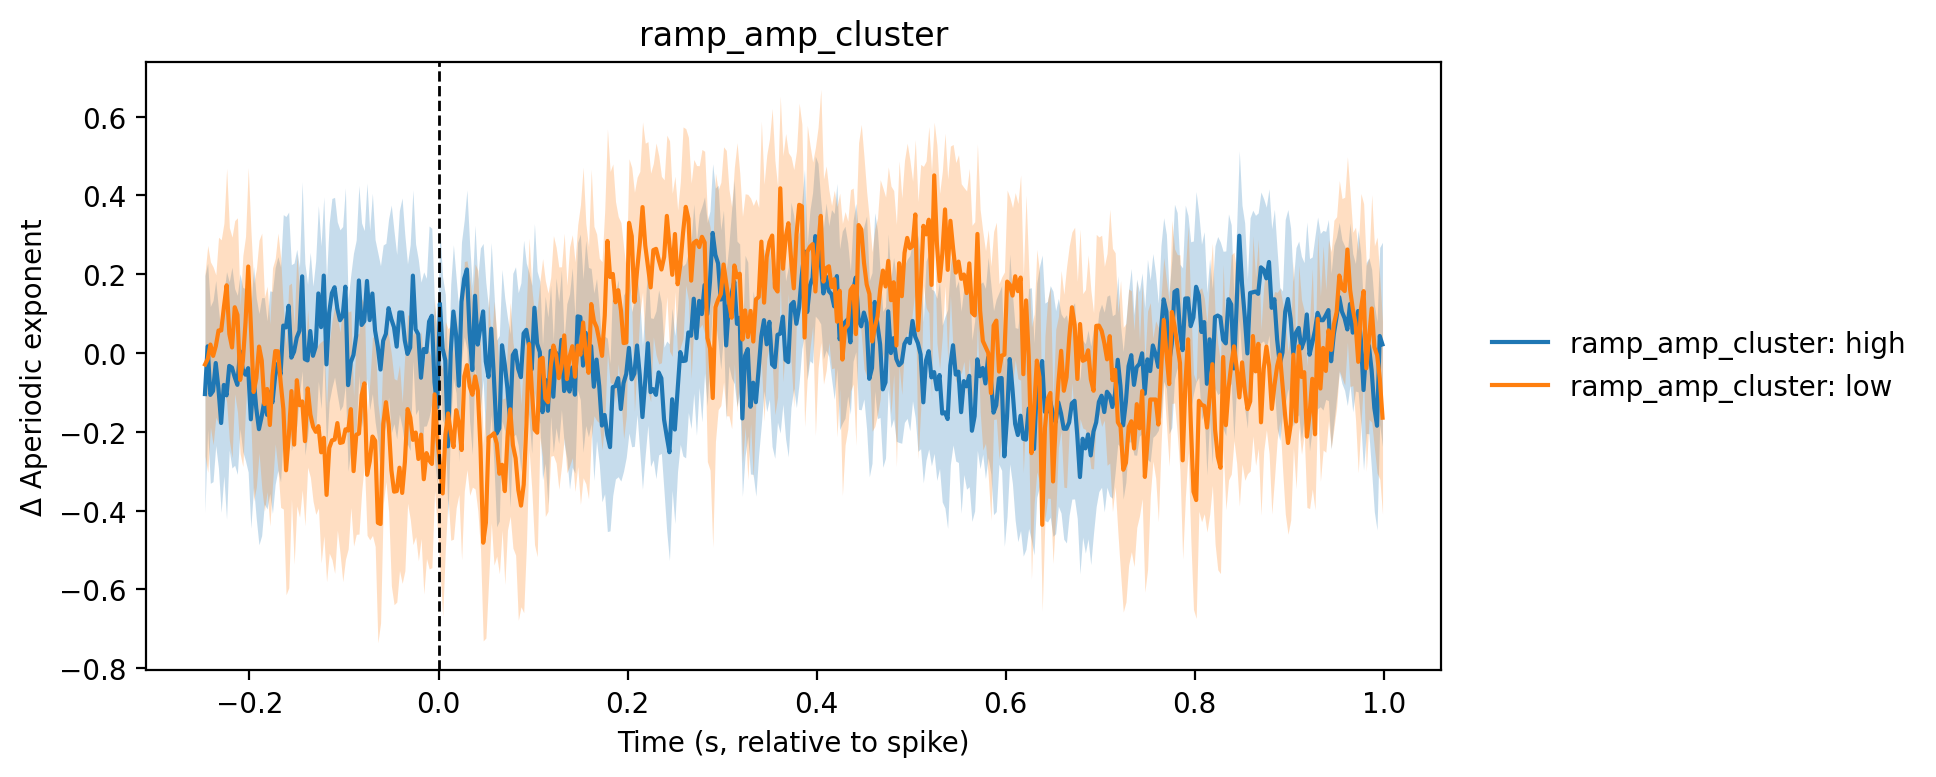

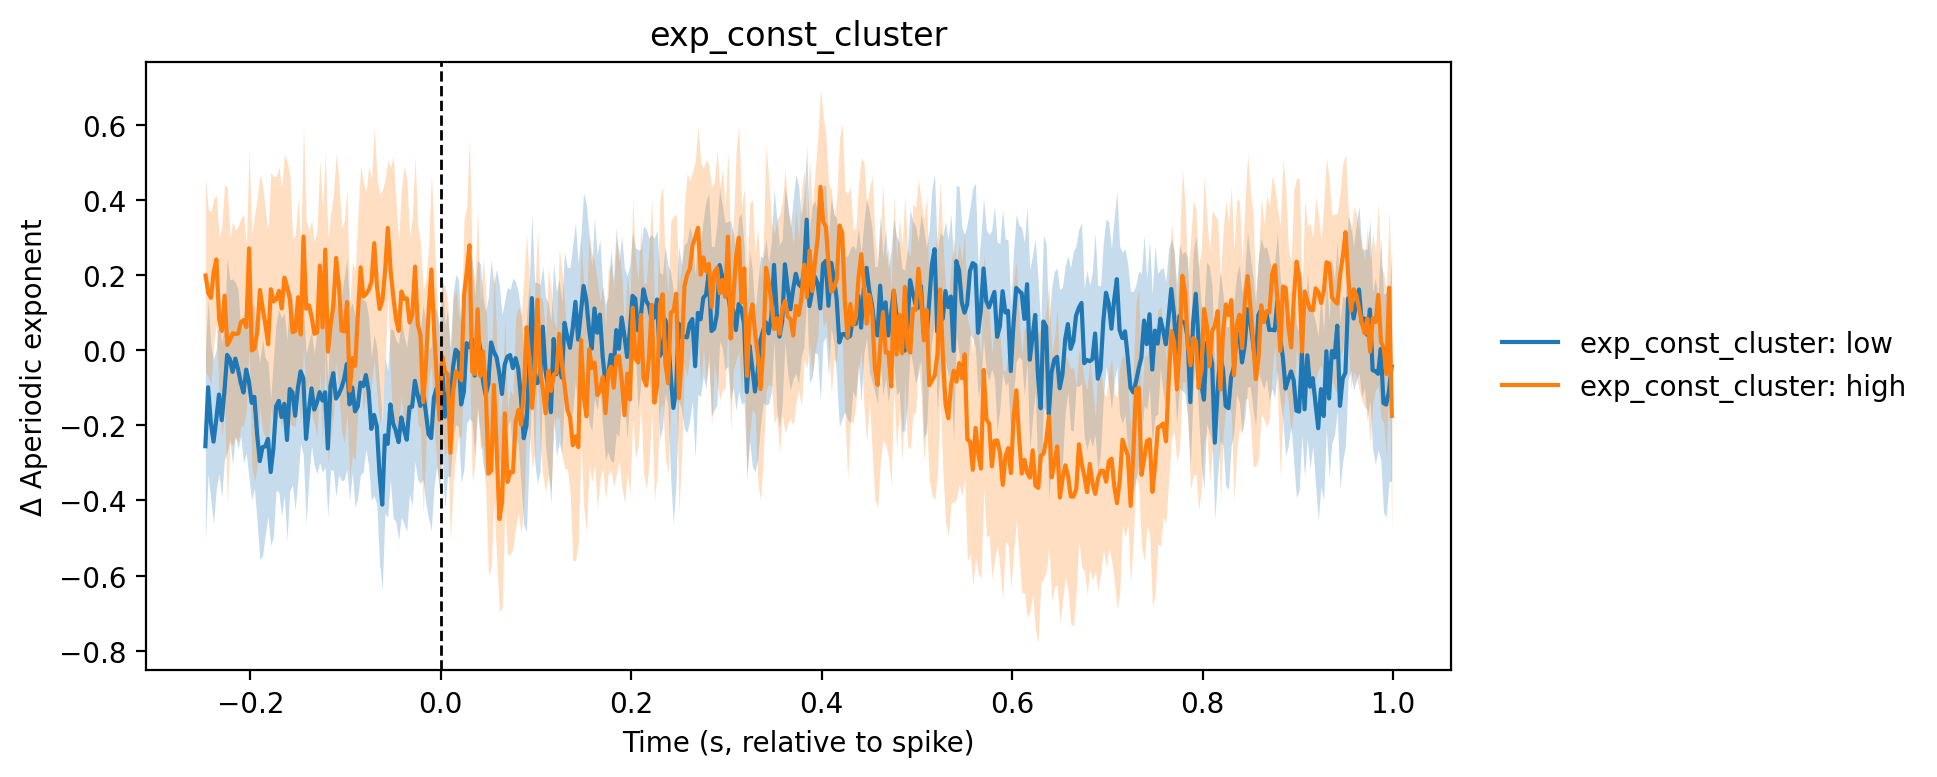

In [56]:
_= window_feature_group_traces_ci_delta(
    exp_groups,
    baseline_window=(-0.5, 1),
    time_unit="s", plot_mode ="per_cluster",ylabel="Δ Aperiodic exponent",
)

#### AUC gamma and aperiodic exponents traces and stats for pre spike window

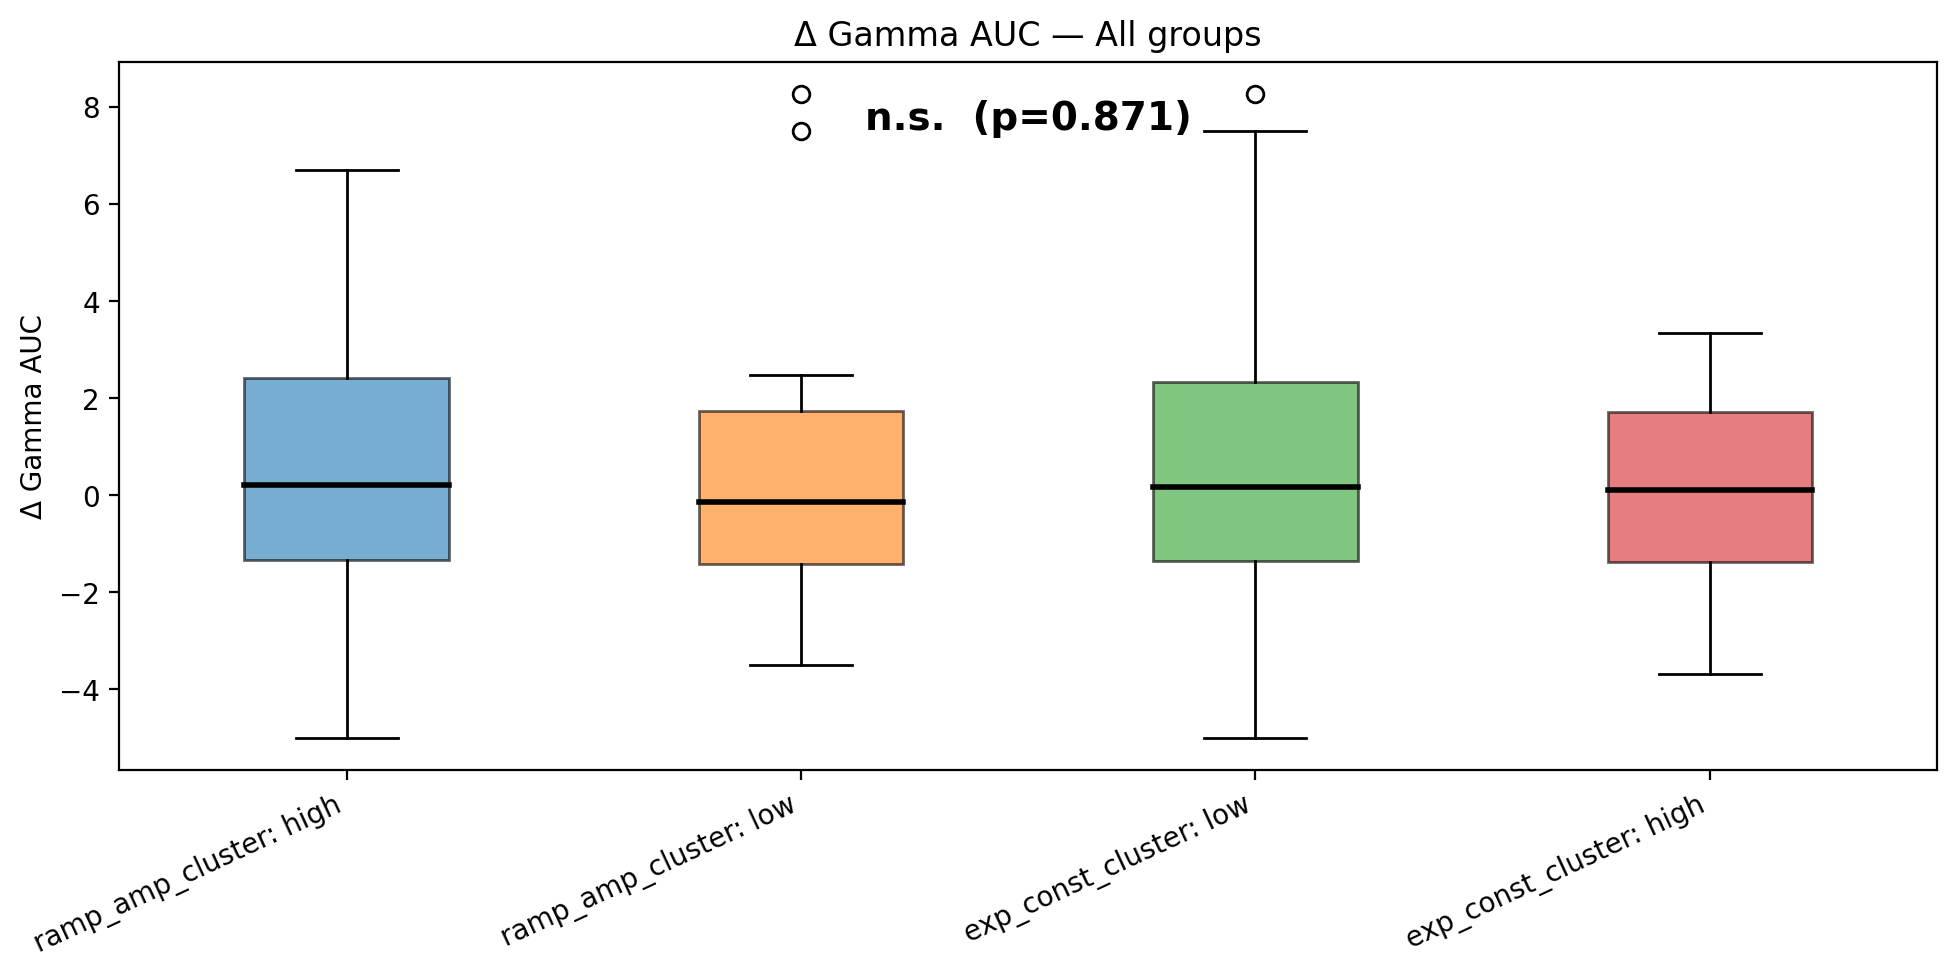

In [57]:
report_all_gamma =stats_boxplot_from_window_results(
    gamma_pre_spike_win,
    plot_mode="all",
    feature_label="Δ Gamma AUC",
)


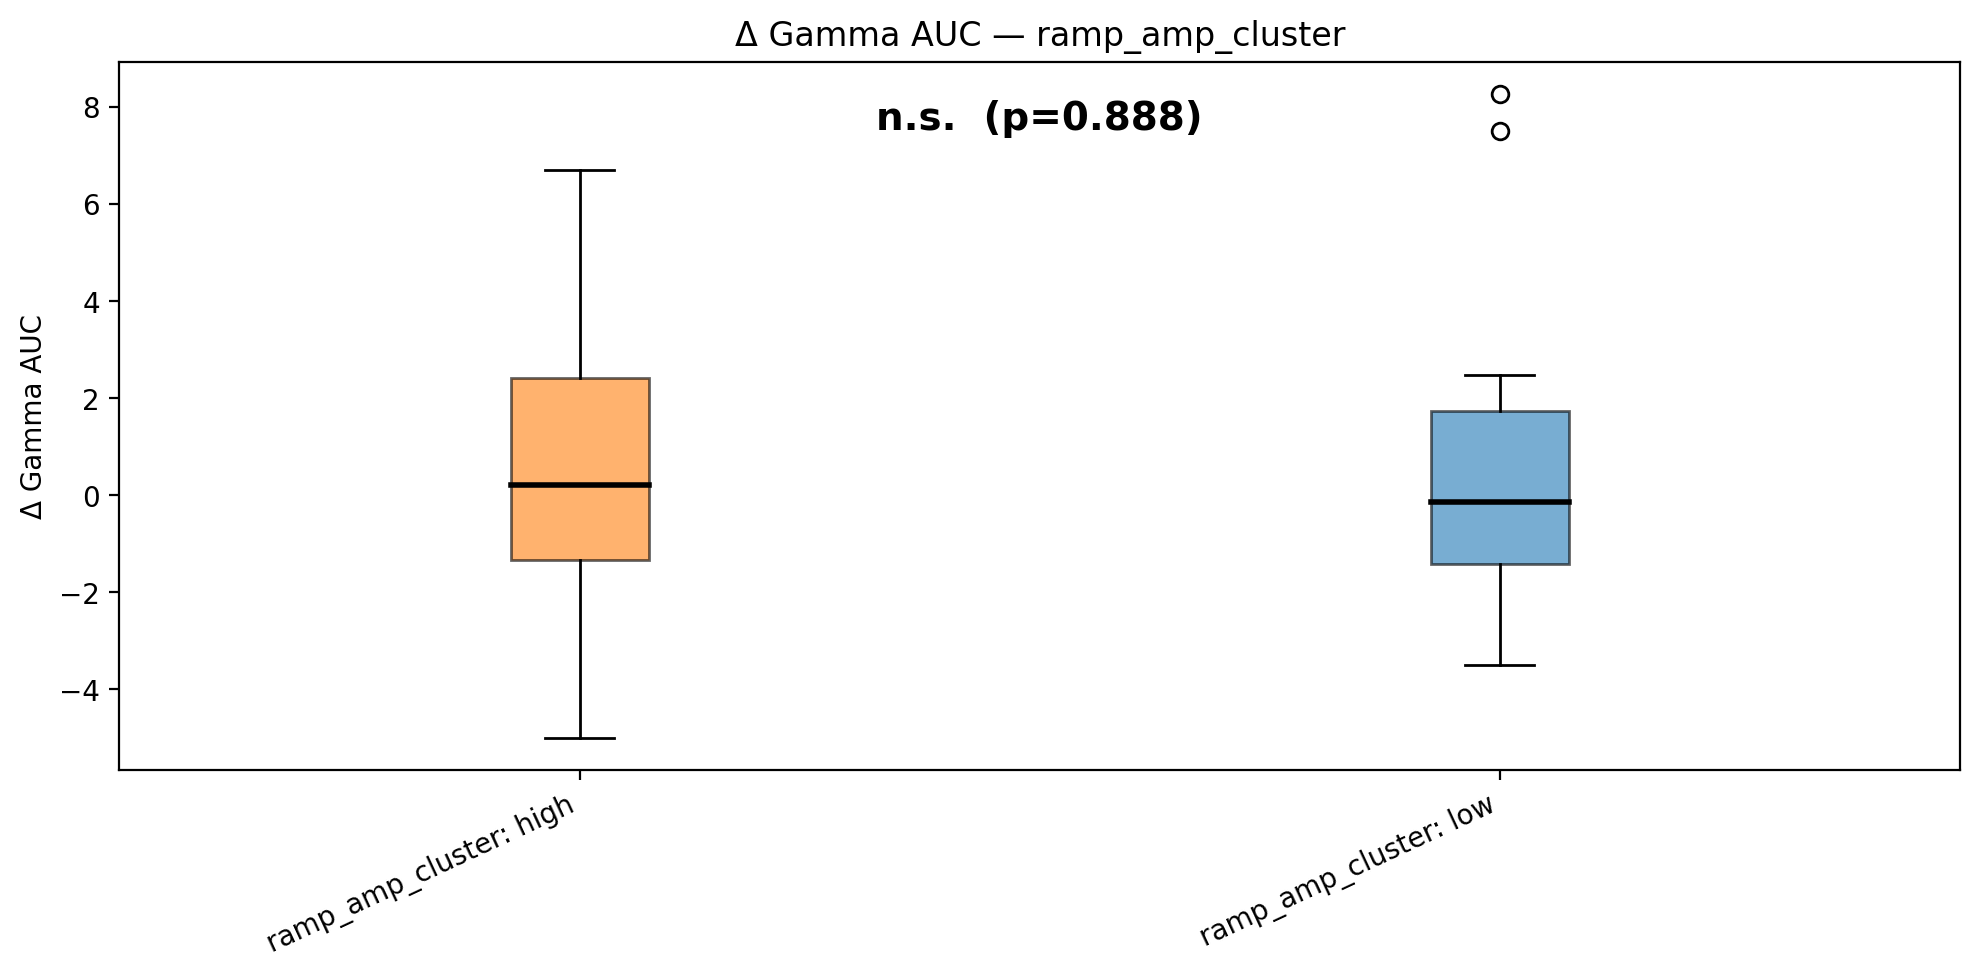

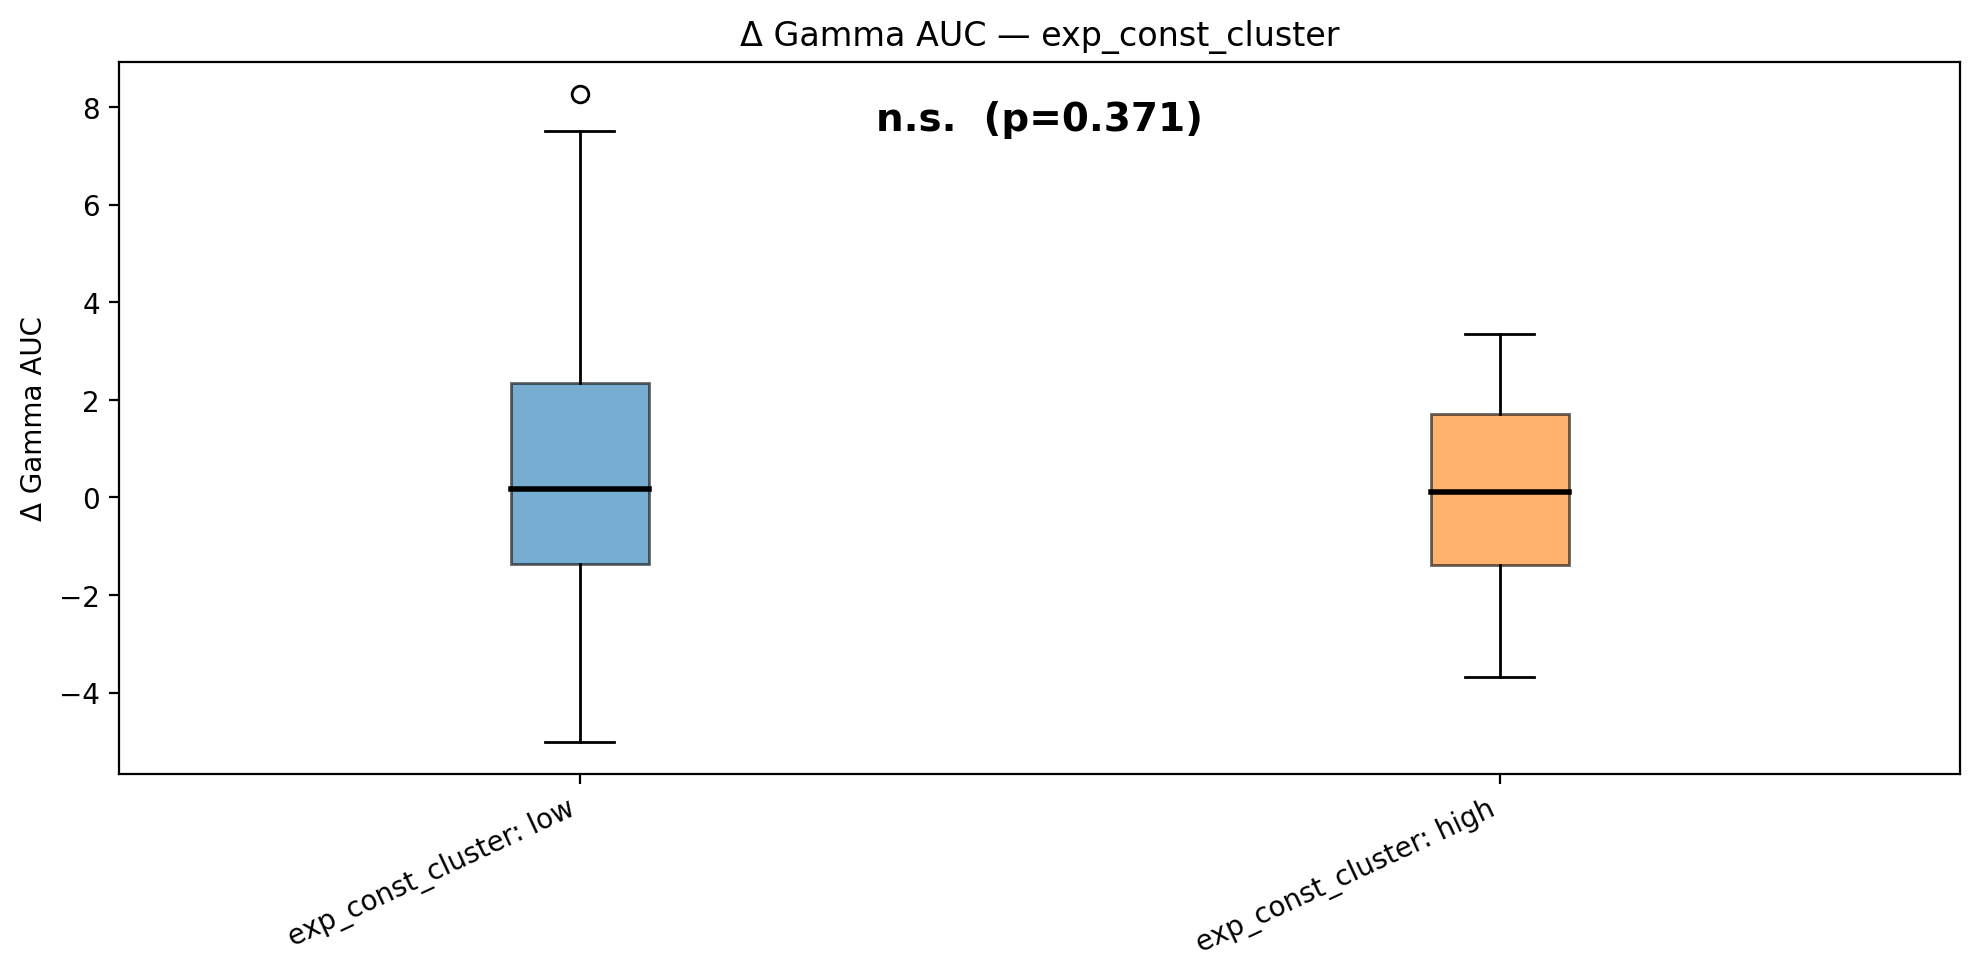

In [58]:
report_all_gamma = stats_boxplot_from_window_results(
    gamma_pre_spike_win,
    plot_mode="per_cluster",
    feature_label="Δ Gamma AUC",
)


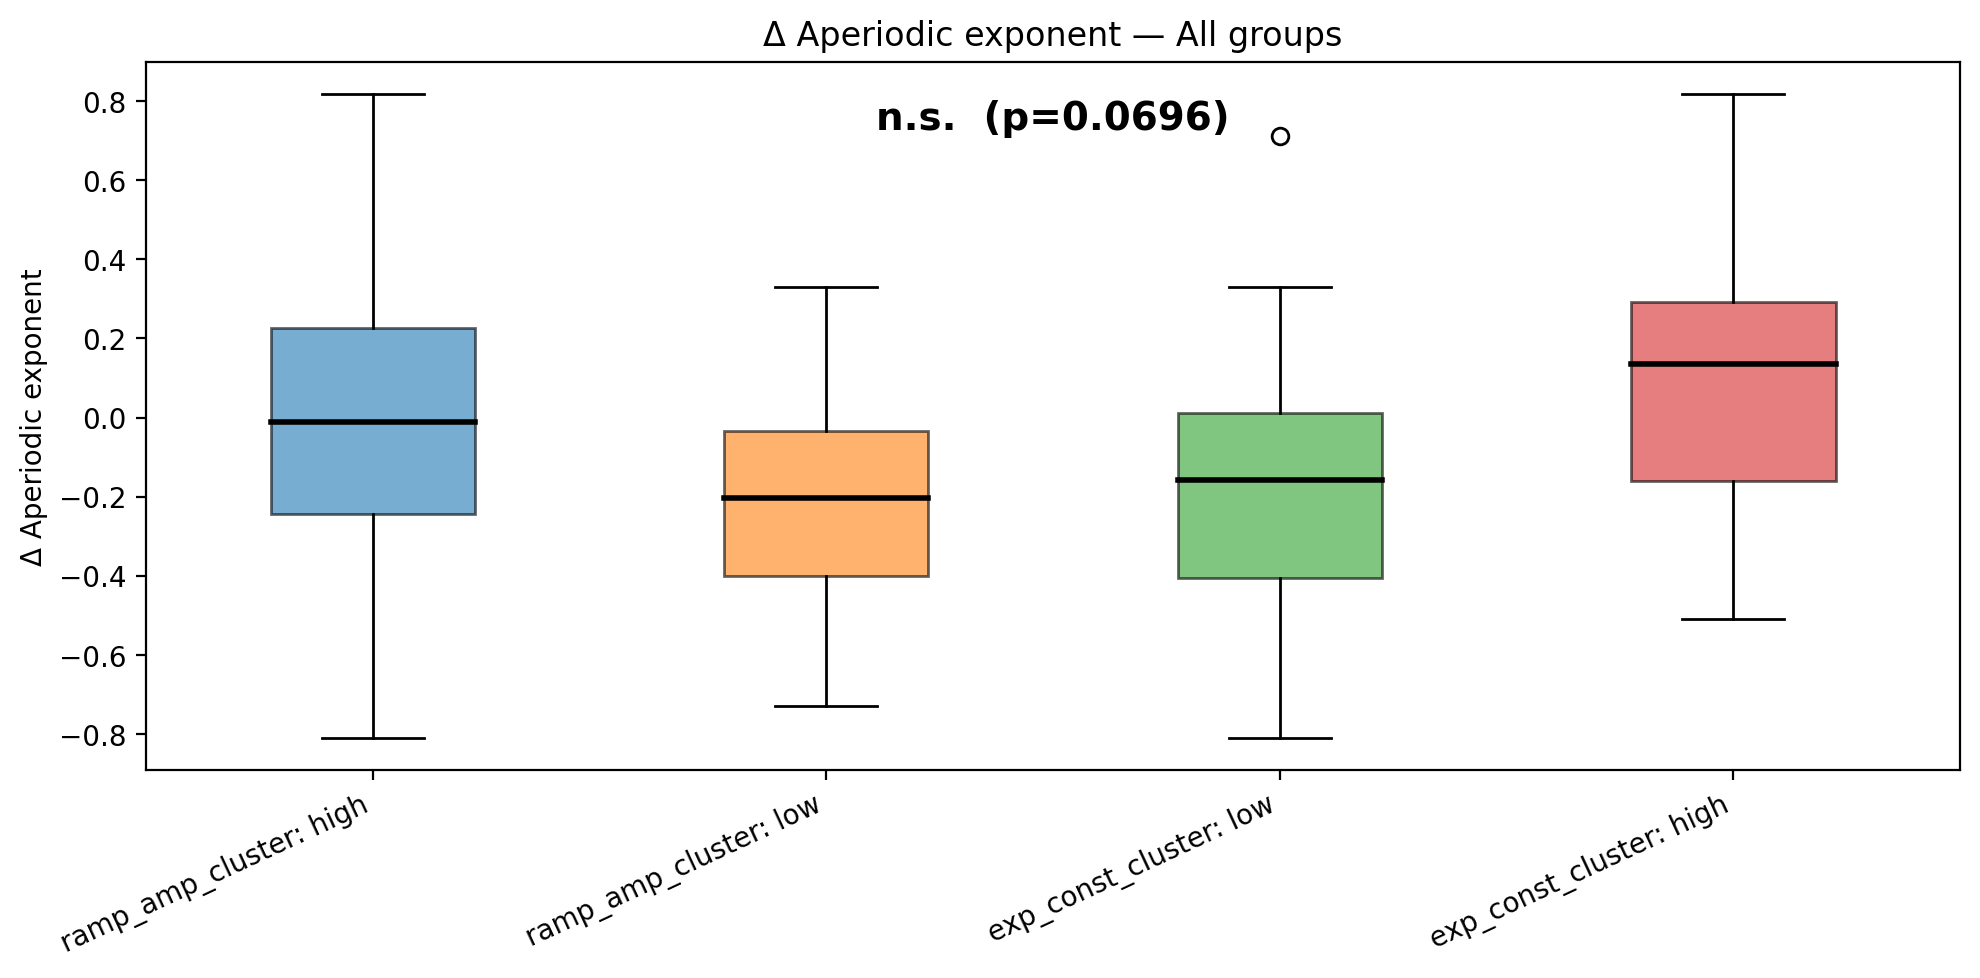

In [59]:
report_all_exp = stats_boxplot_from_window_results(
    exp_pre_spike_win,
    plot_mode="all",
    feature_label="Δ Aperiodic exponent",
)


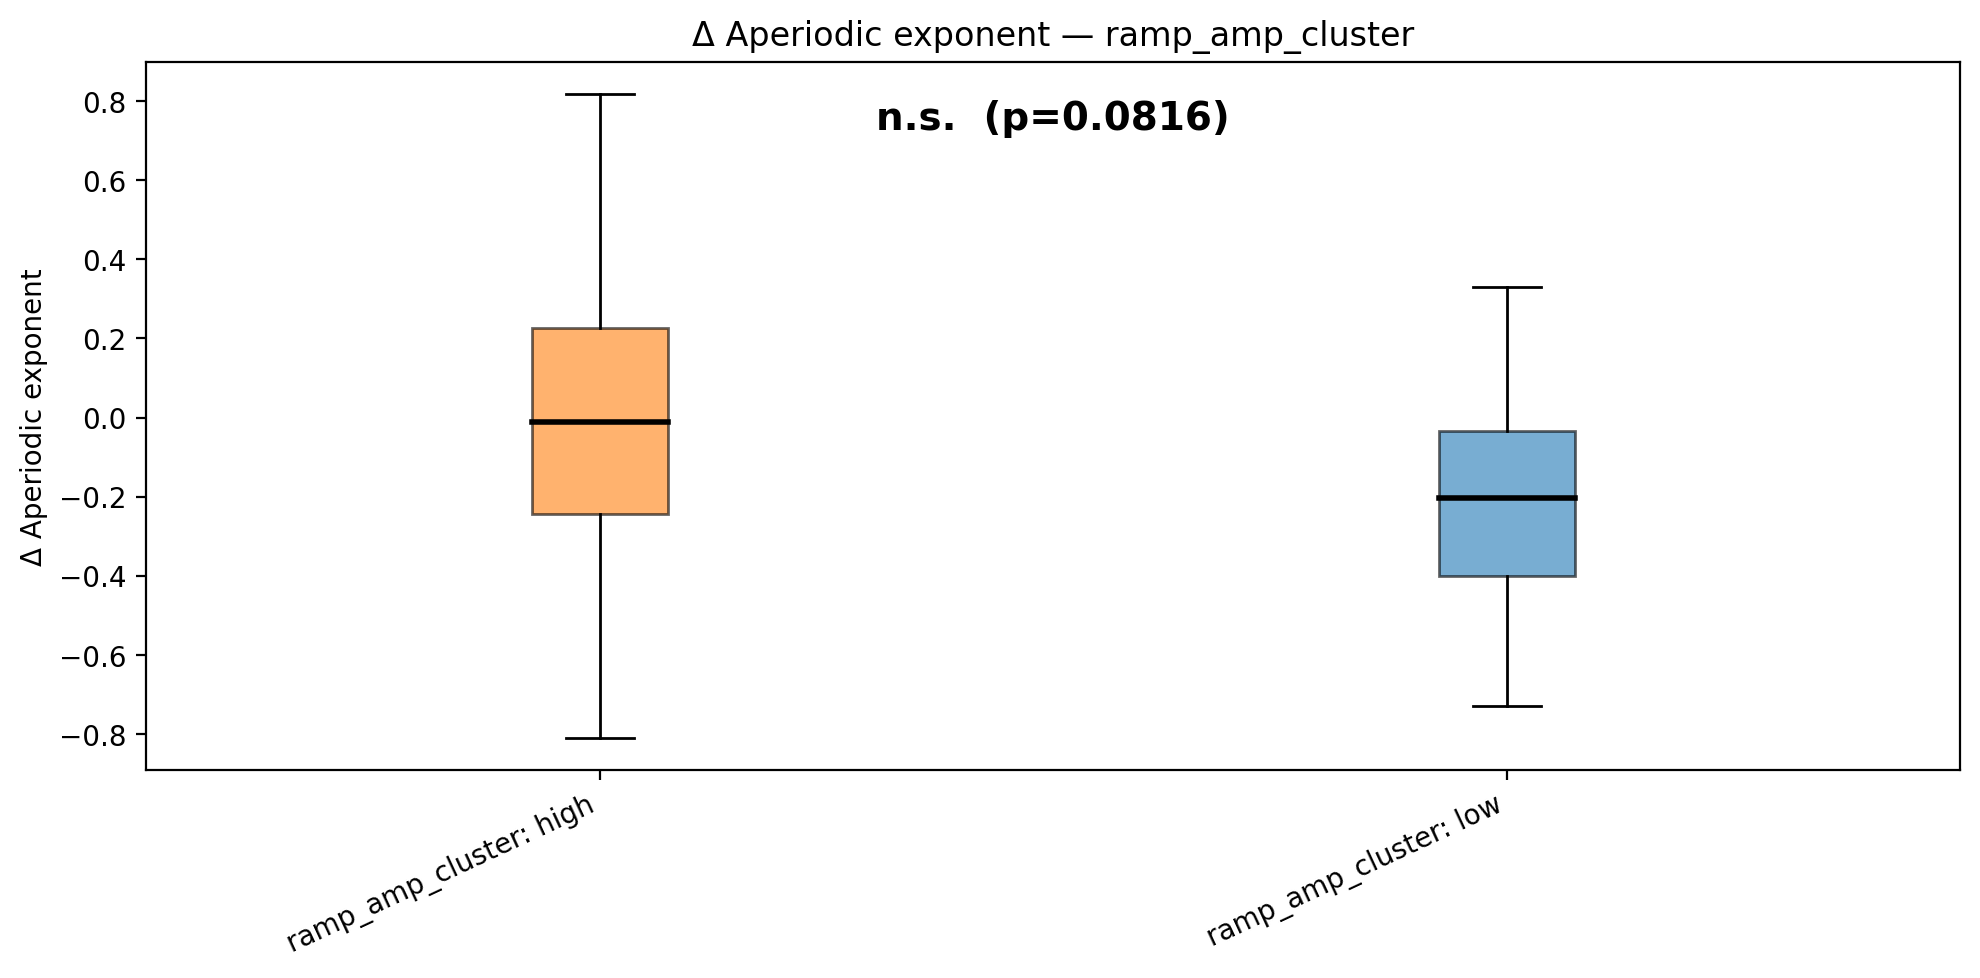

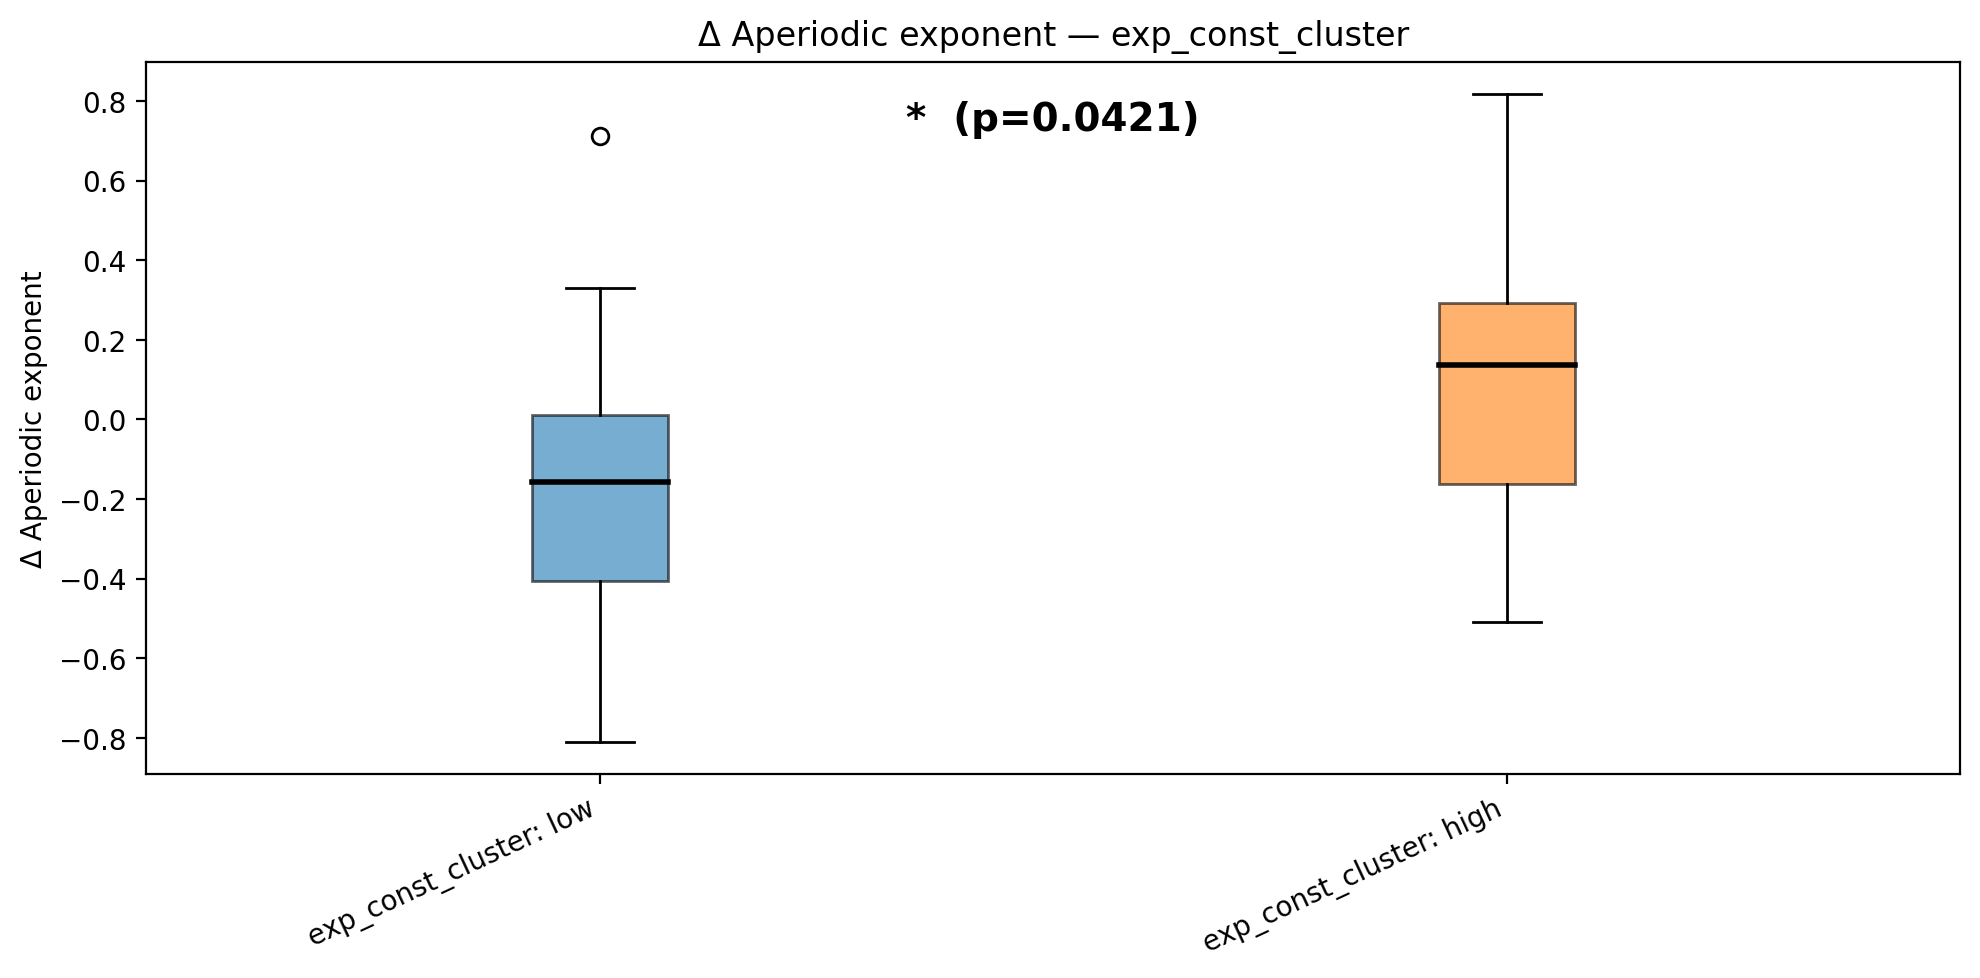

In [60]:
report_all_exp = stats_boxplot_from_window_results(
    exp_pre_spike_win,
    plot_mode="per_cluster",
    feature_label="Δ Aperiodic exponent",
)
